In [1]:
import warnings; warnings.filterwarnings('ignore')
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from linearmodels.panel import PanelOLS
from scipy import stats

REPO  = Path('C:/Users/ADMIN/Desktop/UP/TRABAJO FINAL INGENIERÍA EMPRESARIAL/TFIE_26_2')
DATOS = REPO / 'BD The Box Presentacion 30.08.xlsx'
FIG   = REPO / 'outputs' / 'figuras'
TAB   = REPO / 'outputs' / 'tablas'
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

COLS_RAW = ['anio','semana','fecha','inicio_semana','hora','categoria',
            'nro_tienda','tienda','nombre_tienda','flujo','transacciones','venta','unidades']
EXPECTED_RAW = ['Año','Semana','Fecha','InicioSemana','Hora','Categoria',
                'Nro Tienda','Tienda','Nombre Tienda','Flujo','Transacciones','Venta','Unds Vendidas']
EXPECTED_META = ['Año','Mes','Semana','Categoria','Nro Tienda','Tienda',
                 'Nombre Tienda','Meta','Venta','Cumplimiento']
DAY_NAMES = {1:'Lunes', 2:'Martes', 3:'Miércoles', 4:'Jueves', 5:'Viernes', 6:'Sábado', 7:'Domingo'}
analysis_summary = {}

def normalize_names(names):
    return [unicodedata.normalize('NFKD', str(x)).encode('ascii', 'ignore').decode('ascii').strip().lower() for x in names]

def check_columns(actual, expected, label):
    if normalize_names(actual) != normalize_names(expected):
        raise ValueError(f'{label}: columnas inesperadas.\nActual={actual}\nEsperado={expected}')

def savefig(name):
    plt.savefig(FIG / name, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

def fmt_pct(x, decimals=2):
    return f'{x*100:.{decimals}f}%'

def fmt_pp(x, decimals=2):
    return f'{x*100:.{decimals}f} pp'

def fmt_soles(x, decimals=2):
    return f'S/{x:,.{decimals}f}'

def dual_axis_bar_line(df, x, bar, line, title, xlabel, ylabel_bar, ylabel_line, filename, xlabels=None, line_color='#d62728'):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.bar(df[x], df[bar], color='#9ecae1', alpha=0.9)
    ax2.plot(df[x], df[line], color=line_color, marker='o', linewidth=2)
    ax1.set_title(title)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel_bar)
    ax2.set_ylabel(ylabel_line)
    if xlabels is not None:
        ax1.set_xticks(df[x])
        ax1.set_xticklabels(xlabels)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    savefig(filename)

def weighted_frontier(sw, p):
    q = (sw.groupby('nombre_tienda')
           .apply(lambda g: pd.Series({'q': g['conv'].quantile(p), 'w': g['f'].sum()}))
           .reset_index())
    return float((q['q'] * q['w']).sum() / q['w'].sum())

print(f'Datos: {DATOS}')
print(f'Figuras: {FIG}')
print(f'Tablas: {TAB}')

Datos: C:\Users\ADMIN\Desktop\UP\TRABAJO FINAL INGENIERÍA EMPRESARIAL\TFIE_26_2\BD The Box Presentacion 30.08.xlsx
Figuras: C:\Users\ADMIN\Desktop\UP\TRABAJO FINAL INGENIERÍA EMPRESARIAL\TFIE_26_2\outputs\figuras
Tablas: C:\Users\ADMIN\Desktop\UP\TRABAJO FINAL INGENIERÍA EMPRESARIAL\TFIE_26_2\outputs\tablas


# Bloque 1 — Objetivo, alcance y diccionario de datos

**Objetivo del TFIE.** Construir un diagnóstico cuantitativo de The Box que permita separar problemas de medición, operación y gestión comercial a partir de tráfico, transacciones, ventas y metas.

**Definición operativa.** La conversión se define como `transacciones / flujo`. Se interpreta como una tasa observada de cierre sobre visitas medidas, no como una medida causal de desempeño laboral.

**Cobertura temporal.** La base contiene información para 2025 y 2026, lo que permite comparar desempeño interanual y distinguir hechos verificados de asociaciones estadísticas.

**Diccionario de datos (13 columnas usadas de la hoja `BD Venta por hora`).**

| Columna | Tipo esperado | Descripción |
|---|---|---|
| Año | entero | Año calendario del registro |
| Semana | entero | Semana del año |
| Fecha | fecha | Día del registro |
| InicioSemana | fecha | Fecha de inicio de la semana |
| Hora | entero | Hora de observación |
| Categoria | texto | Línea comercial (`THE BOX` / `COOL BRANDS`) |
| Nro Tienda | entero/texto | Identificador de tienda |
| Tienda | texto | Código corto o alias de tienda |
| Nombre Tienda | texto | Nombre descriptivo de tienda |
| Flujo | numérico | Visitas medidas por el contador |
| Transacciones | numérico | Número de tickets o compras |
| Venta | numérico | Venta monetaria del periodo |
| Unds Vendidas | numérico | Unidades vendidas |

> Muestras usadas: **raw** (todo THE BOX), **dep** (10–21, flujo>0, flujo≥transacciones), **comp/sw26** (semanas 2–34 del año correspondiente) y **tiendas comunes** (presentes en dep 2025 y 2026, semanas 2–34).

In [2]:
raw = pd.read_excel(DATOS, sheet_name='BD Venta por hora', usecols=list(range(13)))
check_columns(raw.columns.tolist(), EXPECTED_RAW, 'BD Venta por hora')
raw.columns = COLS_RAW
raw['fecha'] = pd.to_datetime(raw['fecha'])
raw['inicio_semana'] = pd.to_datetime(raw['inicio_semana'])
raw[['anio','semana','hora','flujo','transacciones','venta','unidades']] = (
    raw[['anio','semana','hora','flujo','transacciones','venta','unidades']]
    .apply(pd.to_numeric, errors='coerce')
)

tb = raw[raw['categoria'].eq('THE BOX')].copy()

print(f'Shape raw: {raw.shape}')
print(f'Shape THE BOX: {tb.shape}')
print(f'Tiendas THE BOX únicas: {tb["nombre_tienda"].nunique()}')
display(raw.head())
display(raw.dtypes.rename('dtype').to_frame())
display(tb[['nro_tienda','tienda','nombre_tienda']].drop_duplicates().sort_values('nombre_tienda').reset_index(drop=True))

analysis_summary['raw'] = {
    'raw_rows': int(len(raw)),
    'tb_rows': int(len(tb)),
    'unique_stores': int(tb['nombre_tienda'].nunique())
}

Shape raw: (122329, 13)
Shape THE BOX: (103790, 13)
Tiendas THE BOX únicas: 16


,anio,semana,fecha,inicio_semana,hora,categoria,nro_tienda,tienda,nombre_tienda,flujo,transacciones,venta,unidades
0,2025,1,2024-12-30,2024-12-30,8,THE BOX,48,TB RPCUS,THE BOX REAL PLAZA CUSCO,4,0,0.00000,0
1,2025,1,2024-12-30,2024-12-30,9,THE BOX,11,TB MACIX,THE BOX MALL AVENTURA CHICLAYO,0,1,193.00000,4
2,2025,1,2024-12-30,2024-12-30,9,THE BOX,48,TB RPCUS,THE BOX REAL PLAZA CUSCO,6,0,0.00000,0
3,2025,1,2024-12-30,2024-12-30,10,THE BOX,1,TB PCSI,THE BOX SAN ISIDRO,3,2,355.00001,3
4,2025,1,2024-12-30,2024-12-30,10,COOL BRANDS,3,CB PLAQ 1,COOLBRANDS AREQUIPA PARQUE LAMBRAMANI,12,3,582.11866,9


,dtype
anio,int64
semana,int64
fecha,datetime64[ns]
inicio_semana,datetime64[ns]
hora,int64
categoria,object
nro_tienda,int64
tienda,object
nombre_tienda,object
flujo,int64


,nro_tienda,tienda,nombre_tienda
0,6,TB JPSU,THE BOX JOCKEY PLAZA
1,56,TB RBBR,THE BOX LA RAMBLA BRASIL
2,20,TB RBSB,THE BOX LA RAMBLA SAN BORJA
3,57,TB LMMIR 2,THE BOX LARCOMAR 2
4,13,TB MAAQP,THE BOX MALL AVENTURA AREQUIPA PORONGOCHE
5,11,TB MACIX,THE BOX MALL AVENTURA CHICLAYO
6,9,TB MASA,THE BOX MALL AVENTURA SANTA ANITA
7,52,TB MPAQP,THE BOX MALL PLAZA AREQUIPA CAYMA
8,18,TB MPTRU,THE BOX MALL PLAZA TRUJILLO
9,42,TB MGCHM,THE BOX MEGA PLAZA CHIMBOTE


# Bloque 2 — Calidad de datos y depuración

**Pregunta.** ¿Qué tan consistente es la medición base y cuánto cambia la conversión al depurar registros evidentemente problemáticos?

**Método.** Se resume la muestra **raw** por año y luego se define la muestra **dep** con tres reglas explícitas:

- `hora` entre 10 y 21;
- `flujo > 0`;
- `flujo ≥ transacciones`.

**Variables foco.** `flujo`, `transacciones`, `venta`, `hora` y `anio`.

> La depuración elimina observaciones incompatibles con una medición operativa razonable, pero no garantiza ausencia de sesgos de conteo.

In [3]:
calidad = (
    tb.groupby('anio')
      .apply(lambda g: pd.Series({
          'filas': len(g),
          'flujo_total': g['flujo'].sum(),
          'trx_total': g['transacciones'].sum(),
          'conv_reportada': g['transacciones'].sum() / g['flujo'].sum(),
          'filas_flujo_cero': int((g['flujo'] == 0).sum()),
          'trx_en_flujo_cero': g.loc[g['flujo'] == 0, 'transacciones'].sum(),
          'pct_trx_flujo_cero': g.loc[g['flujo'] == 0, 'transacciones'].sum() / g['transacciones'].sum(),
          'flujo_hora22': g.loc[g['hora'] == 22, 'flujo'].sum(),
          'trx_hora22': g.loc[g['hora'] == 22, 'transacciones'].sum()
      }))
      .reset_index()
)

esperados_calidad = pd.DataFrame({
    'anio': [2025, 2026],
    'conv_reportada_esperada': [0.06468, 0.06815],
    'pct_trx_flujo_cero_esperada': [0.0711, 0.0484]
})
calidad_comp = calidad.merge(esperados_calidad, on='anio', how='left')
calidad_comp['diff_conv_pp'] = 100 * (calidad_comp['conv_reportada'] - calidad_comp['conv_reportada_esperada'])
calidad_comp['diff_pct_flujo_cero_pp'] = 100 * (calidad_comp['pct_trx_flujo_cero'] - calidad_comp['pct_trx_flujo_cero_esperada'])

reglas = {
    'Fuera de horario 10–21': ~tb['hora'].between(10, 21),
    'flujo = 0': tb['flujo'].eq(0),
    'flujo < transacciones': tb['flujo'] < tb['transacciones']
}
exclusiones = []
for regla, mask in reglas.items():
    exclusiones.append({
        'regla': regla,
        'filas': int(mask.sum()),
        'flujo': float(tb.loc[mask, 'flujo'].sum()),
        'transacciones': float(tb.loc[mask, 'transacciones'].sum()),
        'venta': float(tb.loc[mask, 'venta'].sum())
    })

mask_dep = tb['hora'].between(10, 21) & tb['flujo'].gt(0) & tb['flujo'].ge(tb['transacciones'])
dep = tb.loc[mask_dep].copy()
exclusiones.append({
    'regla': 'Excluidas totales (unión)',
    'filas': int((~mask_dep).sum()),
    'flujo': float(tb.loc[~mask_dep, 'flujo'].sum()),
    'transacciones': float(tb.loc[~mask_dep, 'transacciones'].sum()),
    'venta': float(tb.loc[~mask_dep, 'venta'].sum())
})
exclusiones.append({
    'regla': 'Muestra depurada final',
    'filas': int(len(dep)),
    'flujo': float(dep['flujo'].sum()),
    'transacciones': float(dep['transacciones'].sum()),
    'venta': float(dep['venta'].sum())
})
exclusiones = pd.DataFrame(exclusiones)

conv_dep = dep.groupby('anio').apply(lambda g: g['transacciones'].sum() / g['flujo'].sum()).reset_index(name='conv_depurada')
conv_dep['esperada'] = conv_dep['anio'].map({2025: 0.05973, 2026: 0.06467})
conv_dep['diff_pp'] = 100 * (conv_dep['conv_depurada'] - conv_dep['esperada'])

print(f'Filas totales: {len(raw):,}  — esperado: 122 329')
print(f'Filas THE BOX: {len(tb):,}   — esperado: 103 790')
display(calidad_comp)
display(exclusiones)
display(conv_dep)

calidad_comp.to_csv(TAB / 'calidad_datos.csv', index=False)
exclusiones.to_csv(TAB / 'exclusiones_depuracion.csv', index=False)

analysis_summary['calidad'] = {
    'calidad': calidad_comp.copy(),
    'exclusiones': exclusiones.copy(),
    'conv_dep': conv_dep.copy(),
    'dep_rows': int(len(dep))
}

Filas totales: 122,329  — esperado: 122 329
Filas THE BOX: 103,790   — esperado: 103 790


,anio,filas,flujo_total,trx_total,conv_reportada,filas_flujo_cero,trx_en_flujo_cero,pct_trx_flujo_cero,flujo_hora22,trx_hora22,conv_reportada_esperada,pct_trx_flujo_cero_esperada,diff_conv_pp,diff_pct_flujo_cero_pp
0,2025,59800.0,1339121.0,86615.0,0.064680,3335.0,6156.0,0.071073,143.0,2082.0,0.06468,0.0711,0.000049,-0.002686
1,2026,43990.0,951049.0,64811.0,0.068147,1753.0,3135.0,0.048371,25.0,1532.0,0.06815,0.0484,-0.000314,-0.002858


,regla,filas,flujo,transacciones,venta
0,Fuera de horario 10–21,2828,1648.0,3901.0,1.356841e+06
1,flujo = 0,5088,0.0,9291.0,2.915895e+06
2,flujo < transacciones,5299,406.0,10054.0,3.126655e+06
3,Excluidas totales (unión),5956,2050.0,10083.0,3.136256e+06
4,Muestra depurada final,97834,2288120.0,141343.0,4.581319e+07


,anio,conv_depurada,esperada,diff_pp
0,2025,0.059662,0.05973,-0.006794
1,2026,0.064744,0.06467,0.007384


# Bloque 3 — Evolución 2025–2026 (semanas 2–34)

**Pregunta.** ¿Cuánto crece el negocio entre 2025 y 2026 en semanas comparables y qué parte del cambio proviene de flujo, conversión y ticket?

**Método.** Se usa la muestra **dep** en semanas 2–34. La venta se descompone de forma logarítmica en:

\[
Venta = Flujo \times Conversión \times Ticket
\]

donde `Ticket = Venta / Transacciones`. Además, se repite la comparación en **tiendas comunes** para separar el efecto composición por aperturas/cierres.

,anio,flujo,trx,venta,unid,tiendas,conv,ticket,upt,ppu
0,2025,703705,39133,1.014057e+07,63821,14,0.055610,259.130818,1.630874,158.890746
1,2026,893219,57894,2.054669e+07,82844,16,0.064815,354.901853,1.430960,248.016608


Crecimiento de venta: +102.6%  — esperado: +94.1%
Aporte flujo:      33.8%  — esperado: 35.9%
Aporte conversión: 21.7%  — esperado: 16.5%
Aporte ticket:     44.5%  — esperado: 47.5%
Tiendas comunes: 14
Crecimiento venta tiendas comunes: +85.2%  — esperado: +75.9%


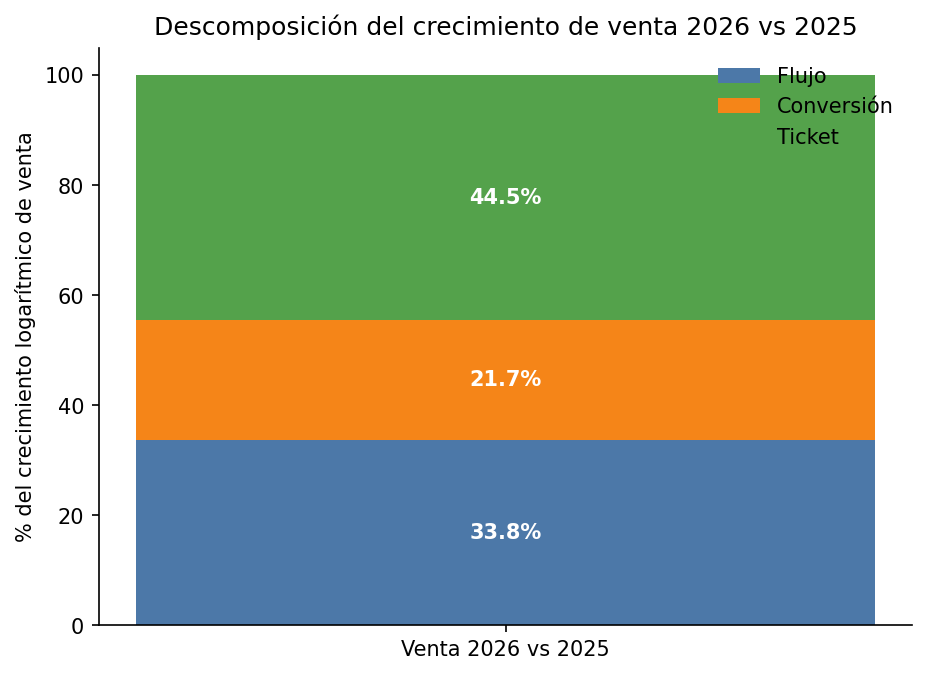

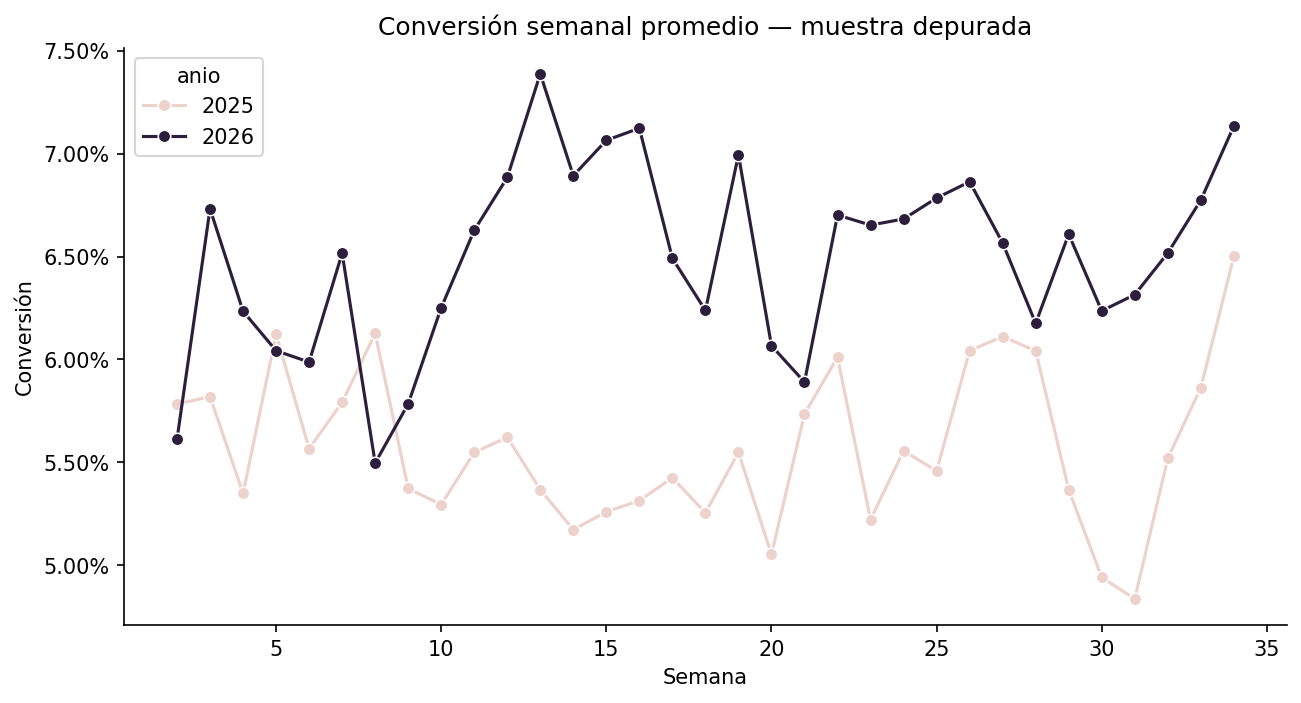

In [4]:
comp = (
    dep[dep['semana'].between(2, 34)]
    .groupby('anio')
    .agg(flujo=('flujo', 'sum'),
         trx=('transacciones', 'sum'),
         venta=('venta', 'sum'),
         unid=('unidades', 'sum'),
         tiendas=('nombre_tienda', 'nunique'))
    .reset_index()
)
comp['conv'] = comp['trx'] / comp['flujo']
comp['ticket'] = comp['venta'] / comp['trx']
comp['upt'] = comp['unid'] / comp['trx']
comp['ppu'] = comp['venta'] / comp['unid']

a = comp.loc[comp['anio'] == 2025].iloc[0]
b = comp.loc[comp['anio'] == 2026].iloc[0]
dlv = np.log(b['venta'] / a['venta'])
decomp = pd.DataFrame({
    'componente': ['Flujo', 'Conversión', 'Ticket'],
    'aporte_pct': [
        100 * np.log(b['flujo'] / a['flujo']) / dlv,
        100 * np.log(b['conv'] / a['conv']) / dlv,
        100 * np.log(b['ticket'] / a['ticket']) / dlv
    ]
})

comunes = sorted(
    set(dep.loc[(dep['anio'] == 2025) & dep['semana'].between(2, 34), 'nombre_tienda'])
    .intersection(set(dep.loc[(dep['anio'] == 2026) & dep['semana'].between(2, 34), 'nombre_tienda']))
)
comp_comunes = (
    dep.loc[dep['semana'].between(2, 34) & dep['nombre_tienda'].isin(comunes)]
       .groupby('anio')
       .agg(flujo=('flujo', 'sum'),
            trx=('transacciones', 'sum'),
            venta=('venta', 'sum'))
)
comp_comunes['conv'] = comp_comunes['trx'] / comp_comunes['flujo']
crecimiento_comunes = comp_comunes.loc[2026, 'venta'] / comp_comunes.loc[2025, 'venta'] - 1

comp_semanal = (
    dep.loc[dep['semana'].between(2, 34)]
       .groupby(['anio', 'semana'])
       .agg(flujo=('flujo', 'sum'), trx=('transacciones', 'sum'))
       .reset_index()
)
comp_semanal['conv'] = comp_semanal['trx'] / comp_semanal['flujo']

display(comp)
print(f"Crecimiento de venta: {(b['venta'] / a['venta'] - 1) * 100:+.1f}%  — esperado: +94.1%")
print(f"Aporte flujo:      {decomp.loc[0, 'aporte_pct']:.1f}%  — esperado: 35.9%")
print(f"Aporte conversión: {decomp.loc[1, 'aporte_pct']:.1f}%  — esperado: 16.5%")
print(f"Aporte ticket:     {decomp.loc[2, 'aporte_pct']:.1f}%  — esperado: 47.5%")
print(f"Tiendas comunes: {len(comunes)}")
print(f"Crecimiento venta tiendas comunes: {crecimiento_comunes * 100:+.1f}%  — esperado: +75.9%")

fig, ax = plt.subplots(figsize=(7, 5))
bottom = 0
colors = ['#4C78A8', '#F58518', '#54A24B']
for (_, row), color in zip(decomp.iterrows(), colors):
    ax.bar(['Venta 2026 vs 2025'], [row['aporte_pct']], bottom=bottom, label=row['componente'], color=color)
    ax.text(0, bottom + row['aporte_pct'] / 2, f"{row['aporte_pct']:.1f}%", ha='center', va='center', color='white', fontweight='bold')
    bottom += row['aporte_pct']
ax.set_ylabel('% del crecimiento logarítmico de venta')
ax.set_title('Descomposición del crecimiento de venta 2026 vs 2025')
ax.legend(frameon=False)
savefig('evolucion_descomposicion.png')

plt.figure(figsize=(10, 5))
sns.lineplot(data=comp_semanal, x='semana', y='conv', hue='anio', marker='o')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.title('Conversión semanal promedio — muestra depurada')
plt.xlabel('Semana')
plt.ylabel('Conversión')
savefig('evolucion_conversion_semanal.png')

analysis_summary['evolucion'] = {
    'comp': comp.copy(),
    'decomp': decomp.copy(),
    'comunes': list(comunes),
    'comp_comunes': comp_comunes.reset_index().copy(),
    'crecimiento_total': float(b['venta'] / a['venta'] - 1),
    'crecimiento_comunes': float(crecimiento_comunes)
}

# Bloque 4 — Conversión real y referencia interna

**Pregunta.** ¿Cuál es la conversión realmente observada en 2026 y qué referencia interna surge del propio desempeño semanal de cada tienda?

**Método.** Se consolida la muestra **sw26** (tienda-semana, 2026, semanas 2–34), filtrando semanas con al menos 100 visitas y 10 transacciones. La referencia interna se construye con percentiles (p75, p90, máximo) de la conversión semanal propia de cada tienda, ponderados por flujo.

> El p90 se usa como una referencia interna observada; no demuestra que ese nivel sea sostenible ni causalmente atribuible a una sola palanca de gestión.

Frontera p 75 = 7.1980%  brecha = 0.7157 pp
Frontera p 90 = 7.7848%  brecha = 1.3025 pp
Frontera p100 = 8.5843%  brecha = 2.1020 pp
Conversión real 2026 sem 2-34: 6.4823%


,nombre_tienda,conv_real,p75,p90,brecha_p90_pp,flujo_total,semanas_validas
15,THE BOX SAN ISIDRO,0.074221,0.100604,0.133939,5.971800,23632.0,33.0
9,THE BOX MEGA PLAZA CHIMBOTE,0.054588,0.060919,0.082334,2.774666,28468.0,27.0
12,THE BOX REAL PLAZA CUSCO,0.085779,0.100678,0.105557,1.977751,30287.0,33.0
2,THE BOX LA RAMBLA SAN BORJA,0.069575,0.080264,0.087092,1.751664,48753.0,33.0
4,THE BOX MALL AVENTURA AREQUIPA PORONGOCHE,0.070970,0.080605,0.086466,1.549624,45442.0,33.0
1,THE BOX LA RAMBLA BRASIL,0.065403,0.074681,0.080327,1.492388,32185.0,33.0
7,THE BOX MALL PLAZA AREQUIPA CAYMA,0.075595,0.081420,0.089867,1.427158,34301.0,33.0
8,THE BOX MALL PLAZA TRUJILLO,0.061358,0.067901,0.074547,1.318892,151031.0,33.0
14,THE BOX REAL PLAZA PURUCHUCO 1,0.076071,0.082430,0.088811,1.274063,39884.0,33.0
5,THE BOX MALL AVENTURA CHICLAYO,0.069711,0.077728,0.081744,1.203367,61081.0,33.0


,percentil,frontera,brecha_pp
0,0.75,0.071980,0.715716
1,0.90,0.077848,1.302507
2,1.00,0.085843,2.102034


,nombre_tienda,semanas_con_10pct
12,THE BOX REAL PLAZA CUSCO,10
15,THE BOX SAN ISIDRO,9
9,THE BOX MEGA PLAZA CHIMBOTE,2


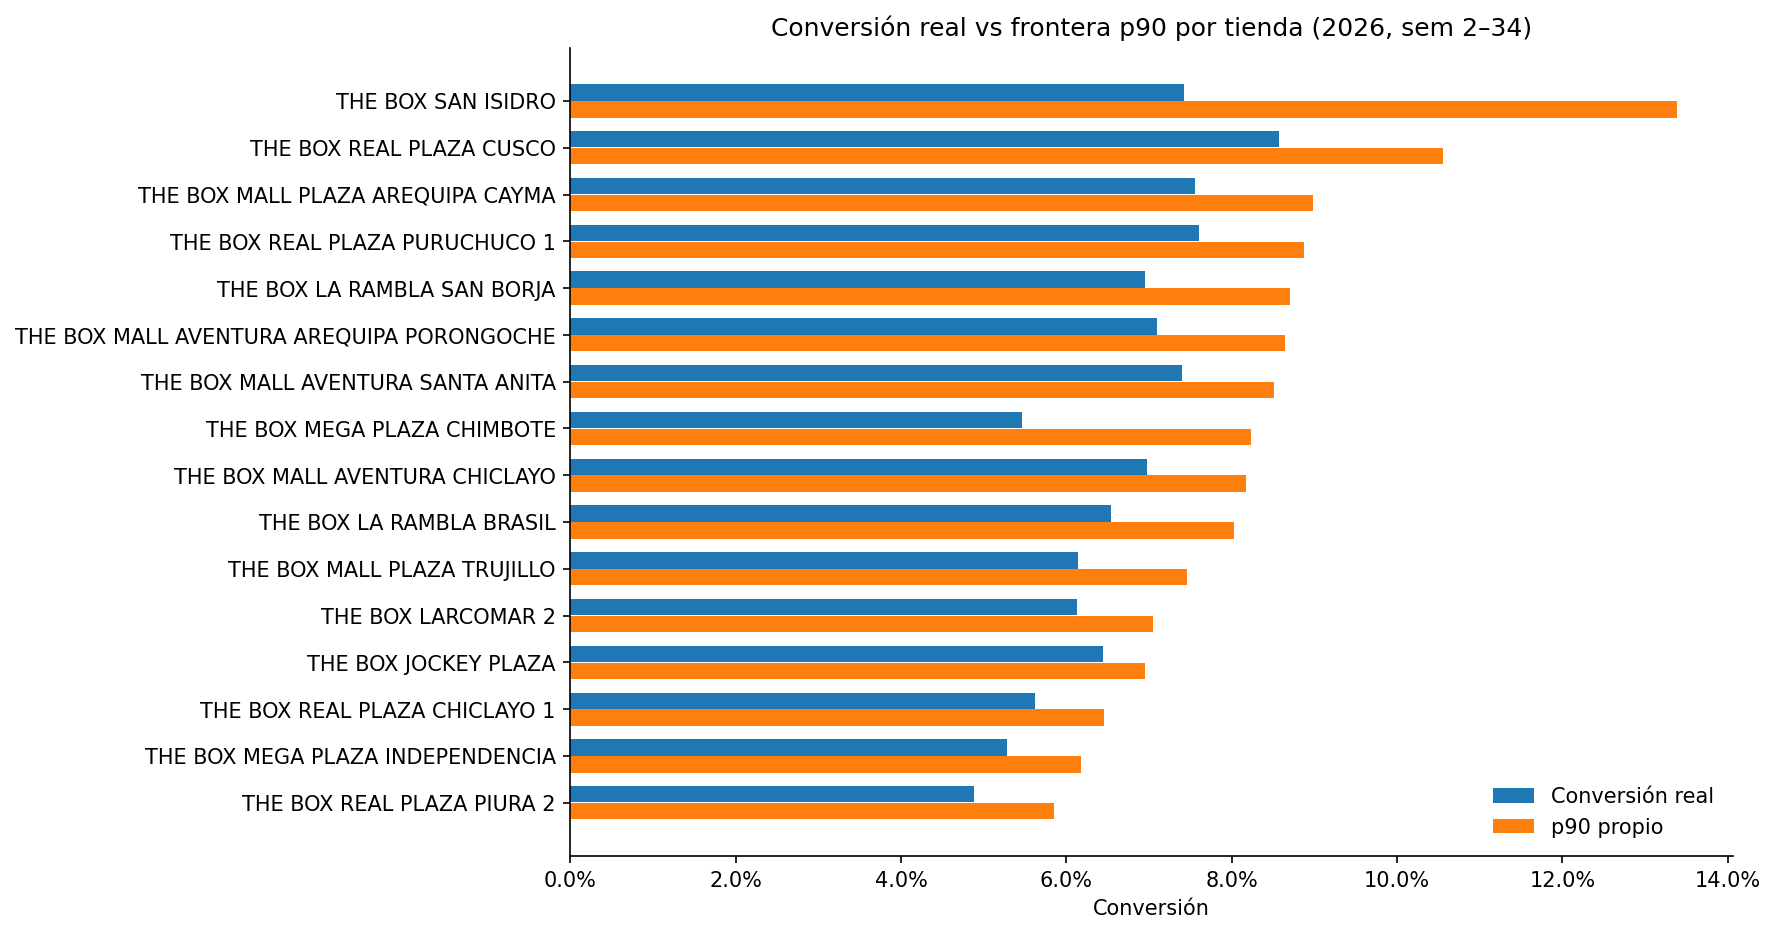

In [5]:
sw26 = (
    dep.loc[(dep['anio'] == 2026) & dep['semana'].between(2, 34)]
       .groupby(['nombre_tienda', 'semana'])
       .agg(f=('flujo', 'sum'),
            t=('transacciones', 'sum'),
            v=('venta', 'sum'),
            u=('unidades', 'sum'))
       .reset_index()
)
sw26 = sw26.loc[(sw26['f'] >= 100) & (sw26['t'] >= 10)].copy()
sw26['conv'] = sw26['t'] / sw26['f']

conv_real = sw26['t'].sum() / sw26['f'].sum()
frontier_results = []
for p in [0.75, 0.90, 1.00]:
    v = weighted_frontier(sw26, p)
    frontier_results.append({'percentil': p, 'frontera': v, 'brecha_pp': 100 * (v - conv_real)})
    print(f"Frontera p{int(p*100):3d} = {v*100:.4f}%  brecha = {(v-conv_real)*100:.4f} pp")

frontera_por_tienda = (
    sw26.groupby('nombre_tienda')
        .apply(lambda g: pd.Series({
            'conv_real': g['t'].sum() / g['f'].sum(),
            'p75': g['conv'].quantile(0.75),
            'p90': g['conv'].quantile(0.90),
            'brecha_p90_pp': 100 * (g['conv'].quantile(0.90) - g['t'].sum() / g['f'].sum()),
            'flujo_total': g['f'].sum(),
            'semanas_validas': len(g)
        }))
        .reset_index()
        .sort_values('brecha_p90_pp', ascending=False)
)
frontera_por_tienda.to_csv(TAB / 'frontera_por_tienda.csv', index=False)

sw_todas = (
    dep.groupby(['nombre_tienda', 'anio', 'semana'])
       .agg(f=('flujo', 'sum'), t=('transacciones', 'sum'))
       .reset_index()
)
sw_todas = sw_todas.loc[sw_todas['f'] >= 300].copy()
sw_todas['conv'] = sw_todas['t'] / sw_todas['f']

print(f"Conversión real 2026 sem 2-34: {conv_real*100:.4f}%")
display(frontera_por_tienda)
display(pd.DataFrame(frontier_results))
display(
    sw_todas.loc[sw_todas['anio'] == 2026]
            .assign(conv10=lambda df: df['conv'] >= 0.10)
            .groupby('nombre_tienda')['conv10']
            .sum()
            .reset_index(name='semanas_con_10pct')
            .query('semanas_con_10pct > 0')
            .sort_values('semanas_con_10pct', ascending=False)
)

order = frontera_por_tienda.sort_values('p90').index
plot_df = frontera_por_tienda.loc[order]
y = np.arange(len(plot_df))
plt.figure(figsize=(10, 7))
plt.barh(y + 0.18, plot_df['conv_real'], height=0.35, label='Conversión real')
plt.barh(y - 0.18, plot_df['p90'], height=0.35, label='p90 propio')
plt.yticks(y, plot_df['nombre_tienda'])
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xlabel('Conversión')
plt.title('Conversión real vs frontera p90 por tienda (2026, sem 2–34)')
plt.legend(frameon=False)
savefig('frontera_conversion.png')

analysis_summary['frontera'] = {
    'conv_real': float(conv_real),
    'frontiers': pd.DataFrame(frontier_results),
    'frontera_por_tienda': frontera_por_tienda.copy()
}

# Bloque 5 — Relación tráfico–conversión

**Pregunta.** ¿La conversión se asocia negativamente con mayor tráfico al controlar por heterogeneidad observable básica?

**Método.**

1. **Panel hora** con efectos fijos de `tienda_hora` y `fecha`, agrupando errores por tienda.
2. **Panel semana** con efectos fijos de tienda y de periodo `anio-semana`.
3. **Corte transversal** entre tiendas con Pearson y Spearman.

**Nota metodológica.** `linearmodels.PanelOLS` permite absorber efectos fijos de entidad y tiempo; aquí se aproxima la especificación del script R usando `tienda_hora` como entidad en el panel horario y `nombre_tienda` como entidad en el panel semanal. Estos modelos reducen heterogeneidad fija, pero **no eliminan todos los confusores**.

> Una relación negativa tráfico–conversión puede reflejar congestión, mezcla distinta de visitantes o errores de medición del contador. **No demuestra causalidad ni falta de personal.**

                          PanelOLS Estimation Summary                           
Dep. Variable:                   conv   R-squared:                        0.0113
Estimator:                   PanelOLS   R-squared (Between):             -2.6192
No. Observations:               38866   R-squared (Within):              -0.0112
Date:                Tue, Oct 06 2026   R-squared (Overall):             -1.7714
Time:                        10:45:10   Log-likelihood                 6.603e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      434.64
Entities:                         192   P-value                           0.0000
Avg Obs:                       202.43   Distribution:                 F(1,38071)
Min Obs:                       1.0000                                           
Max Obs:                       584.00   F-statistic (robust):             36.518
                            

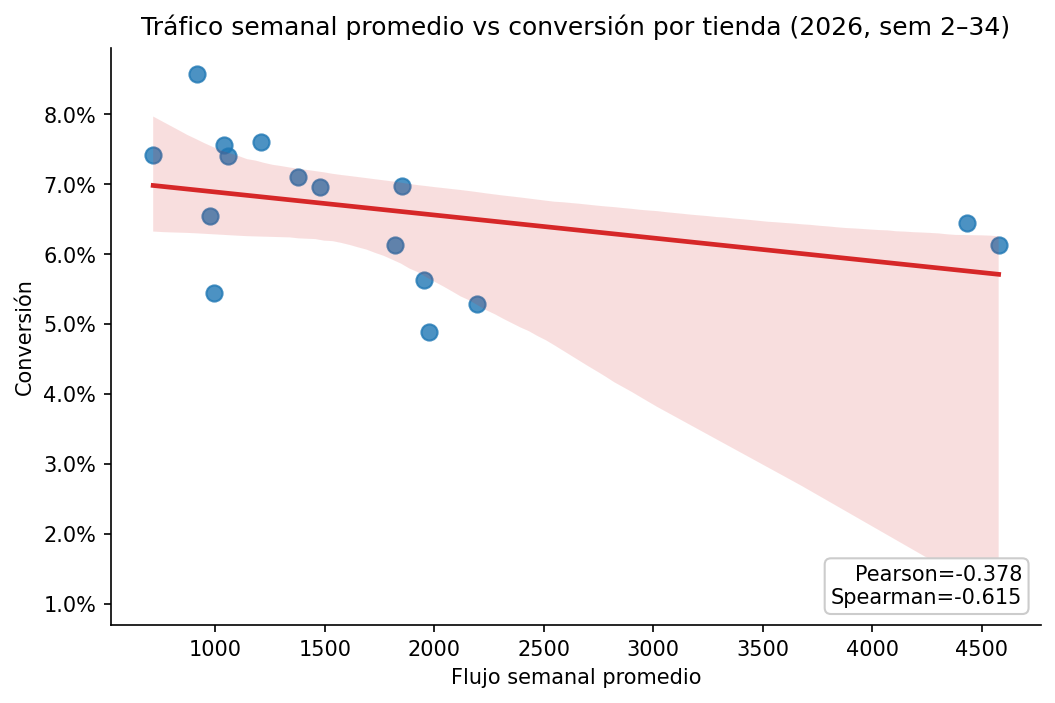

,modelo,n,coef,se,pvalue
0,Panel hora FE tienda_hora + fecha,38866,-0.015830,0.002619,1.526447e-09
1,Panel semana FE tienda + periodo,1228,-0.048966,0.024786,4.845191e-02
2,Corte transversal Pearson,16,-0.377783,NaN,1.491150e-01
3,Corte transversal Spearman,16,-0.614706,NaN,1.127947e-02
4,Spearman sin rupturas,14,-0.758242,NaN,1.673003e-03


In [6]:
h = dep.loc[dep['flujo'] >= 20].copy()
h['conv'] = h['transacciones'] / h['flujo']
h['lf'] = np.log(h['flujo'])
h['tienda_hora'] = h['nombre_tienda'] + '_' + h['hora'].astype(str)

hpanel = h.set_index(['tienda_hora', 'fecha']).sort_index()
clusters_h = pd.DataFrame(
    {'cluster_store': pd.Categorical(hpanel['nombre_tienda']).codes},
    index=hpanel.index
)
m1 = PanelOLS(
    hpanel['conv'],
    hpanel[['lf']],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_h)
beta1 = float(m1.params['lf'])
effect_10pct = beta1 * np.log(1.1) * 100

print(m1.summary)
print(f"\n+10% flujo horario => {effect_10pct:.4f} pp de conversión — esperado: -0.1509 pp")

swp = (
    dep.groupby(['nombre_tienda', 'anio', 'semana'])
       .agg(f=('flujo', 'sum'), t=('transacciones', 'sum'))
       .reset_index()
)
swp = swp.loc[swp['f'] >= 200].copy()
swp['conv'] = swp['t'] / swp['f']
swp['lf'] = np.log(swp['f'])
swp['periodo_id'] = swp['anio'] * 100 + swp['semana']
swp2 = swp.set_index(['nombre_tienda', 'periodo_id']).sort_index()
clusters_s = pd.DataFrame(
    {'cluster_store': pd.Categorical(swp2.index.get_level_values(0)).codes},
    index=swp2.index
)
m2 = PanelOLS(
    swp2['conv'],
    swp2[['lf']],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_s)
print(m2.summary)

ct = (
    dep.loc[(dep['anio'] == 2026) & dep['semana'].between(2, 34)]
       .groupby('nombre_tienda')
       .agg(f=('flujo', 'sum'),
            t=('transacciones', 'sum'),
            sem_activas=('semana', 'nunique'))
       .reset_index()
)
ct['conv'] = ct['t'] / ct['f']
ct['flujo_sem'] = ct['f'] / ct['sem_activas']

r_p, p_p = stats.pearsonr(ct['flujo_sem'], ct['conv'])
r_s, p_s = stats.spearmanr(ct['flujo_sem'], ct['conv'])
ct2 = ct.loc[~ct['nombre_tienda'].str.contains('SAN ISIDRO|CHIMBOTE', regex=True)].copy()
r_s2, p_s2 = stats.spearmanr(ct2['flujo_sem'], ct2['conv'])

print(f"Pearson  r={r_p:.3f} p={p_p:.3f}  — esperado: r=-0.378, p=0.149")
print(f"Spearman r={r_s:.3f} p={p_s:.3f}  — esperado: r=-0.615, p=0.011")
print(f"Spearman sin rupturas r={r_s2:.3f} p={p_s2:.3f}  — esperado: r=-0.758, p=0.002")

plt.figure(figsize=(8, 5))
sns.regplot(data=ct, x='flujo_sem', y='conv', scatter_kws={'s': 60}, line_kws={'color': '#d62728'})
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.title('Tráfico semanal promedio vs conversión por tienda (2026, sem 2–34)')
plt.xlabel('Flujo semanal promedio')
plt.ylabel('Conversión')
plt.annotate(f"Pearson={r_p:.3f}\nSpearman={r_s:.3f}", xy=(0.98, 0.03), xycoords='axes fraction',
             ha='right', va='bottom', bbox=dict(boxstyle='round', fc='white', ec='0.8'))
savefig('scatter_flujo_conversion.png')

modelos = pd.DataFrame([
    {'modelo': 'Panel hora FE tienda_hora + fecha', 'n': int(m1.nobs), 'coef': beta1, 'se': float(m1.std_errors['lf']), 'pvalue': float(m1.pvalues['lf'])},
    {'modelo': 'Panel semana FE tienda + periodo', 'n': int(m2.nobs), 'coef': float(m2.params['lf']), 'se': float(m2.std_errors['lf']), 'pvalue': float(m2.pvalues['lf'])},
    {'modelo': 'Corte transversal Pearson', 'n': int(len(ct)), 'coef': float(r_p), 'se': np.nan, 'pvalue': float(p_p)},
    {'modelo': 'Corte transversal Spearman', 'n': int(len(ct)), 'coef': float(r_s), 'se': np.nan, 'pvalue': float(p_s)},
    {'modelo': 'Spearman sin rupturas', 'n': int(len(ct2)), 'coef': float(r_s2), 'se': np.nan, 'pvalue': float(p_s2)}
])
modelos.to_csv(TAB / 'modelos_trafico_conversion.csv', index=False)
display(modelos)

analysis_summary['trafico_conversion'] = {
    'm1': {'nobs': int(m1.nobs), 'beta': beta1, 'se': float(m1.std_errors['lf']), 'pvalue': float(m1.pvalues['lf']), 'effect_10pct_pp': float(effect_10pct)},
    'm2': {'nobs': int(m2.nobs), 'beta': float(m2.params['lf']), 'se': float(m2.std_errors['lf']), 'pvalue': float(m2.pvalues['lf'])},
    'ct': {'pearson_r': float(r_p), 'pearson_p': float(p_p), 'spearman_r': float(r_s), 'spearman_p': float(p_s), 'spearman_r_no_breaks': float(r_s2), 'spearman_p_no_breaks': float(p_s2)},
    'modelos': modelos.copy(),
    'ct_df': ct.copy()
}

# Bloque 6 — Varianza dentro y entre tiendas

**Pregunta.** ¿La heterogeneidad de la conversión está principalmente entre tiendas o dentro de cada tienda a lo largo de las semanas?

**Método.** Sobre la muestra tienda-semana con `f >= 300`, se estima cuánto explican las dummies de tienda, de semana y ambas en conjunto sobre la conversión semanal. También se compara la dispersión **entre tiendas** con la dispersión promedio **dentro de tienda**.

R² tienda = 0.332  — esperado: 0.332
R² semana = 0.080  — esperado: 0.080
R² ambos  = 0.420  — esperado: 0.420
SD entre tiendas = 0.00999  — esperado: 0.00999
SD dentro promedio = 0.01200  — esperado: 0.01200


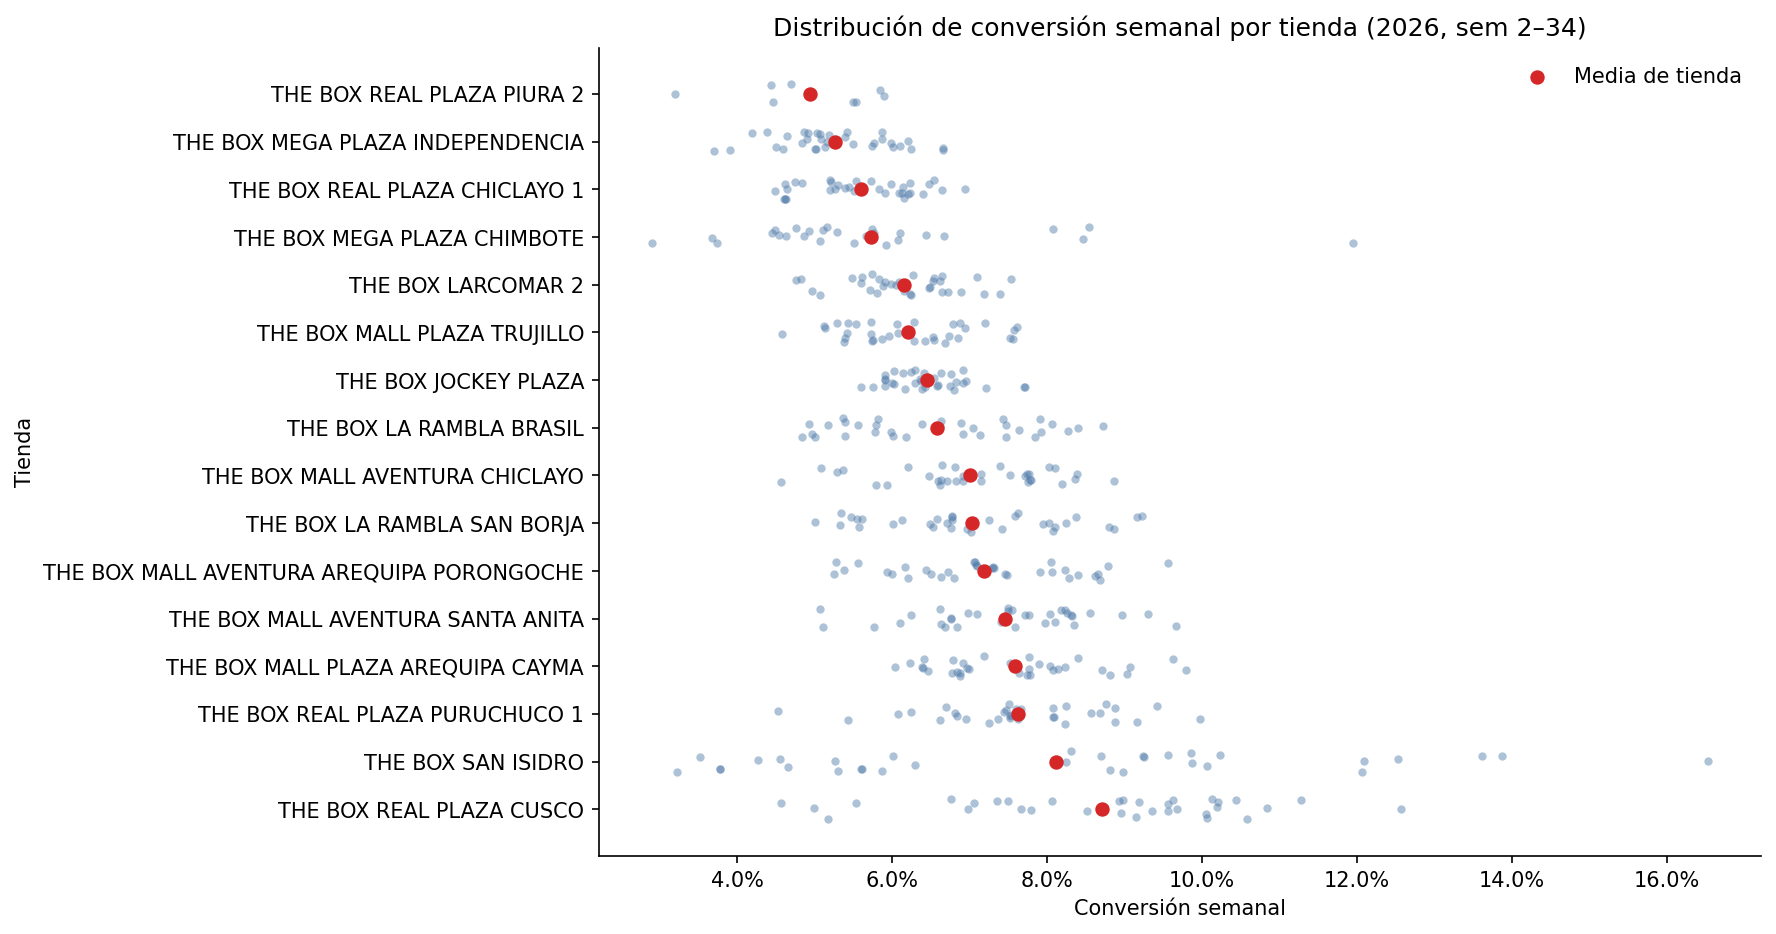

In [7]:
vr = sw_todas.loc[(sw_todas['anio'] == 2026) & sw_todas['semana'].between(2, 34)].copy()

r2_tienda = smf.ols('conv ~ C(nombre_tienda)', data=vr).fit().rsquared
r2_semana = smf.ols('conv ~ C(semana)', data=vr).fit().rsquared
r2_ambos = smf.ols('conv ~ C(nombre_tienda) + C(semana)', data=vr).fit().rsquared

sd_entre = vr.groupby('nombre_tienda').apply(lambda g: g['t'].sum() / g['f'].sum()).std()
sd_dentro = vr.groupby('nombre_tienda')['conv'].std().mean()

print(f"R² tienda = {r2_tienda:.3f}  — esperado: 0.332")
print(f"R² semana = {r2_semana:.3f}  — esperado: 0.080")
print(f"R² ambos  = {r2_ambos:.3f}  — esperado: 0.420")
print(f"SD entre tiendas = {sd_entre:.5f}  — esperado: 0.00999")
print(f"SD dentro promedio = {sd_dentro:.5f}  — esperado: 0.01200")

order = vr.groupby('nombre_tienda')['conv'].mean().sort_values().index
mean_store = vr.groupby('nombre_tienda')['conv'].mean().reindex(order).reset_index(name='mean_conv')

plt.figure(figsize=(10, 7))
sns.stripplot(data=vr, x='conv', y='nombre_tienda', order=order, jitter=0.22, alpha=0.45, size=4, color='#4C78A8')
plt.scatter(mean_store['mean_conv'], np.arange(len(mean_store)), color='#d62728', s=35, label='Media de tienda', zorder=10)
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xlabel('Conversión semanal')
plt.ylabel('Tienda')
plt.title('Distribución de conversión semanal por tienda (2026, sem 2–34)')
plt.legend(frameon=False)
savefig('varianza_conversion_tienda.png')

analysis_summary['varianza'] = {
    'r2_tienda': float(r2_tienda),
    'r2_semana': float(r2_semana),
    'r2_ambos': float(r2_ambos),
    'sd_entre': float(sd_entre),
    'sd_dentro': float(sd_dentro)
}

# Bloque 7 — Patrones por hora y día

**Pregunta.** ¿Existen franjas horarias o días de la semana con mezcla operativa distinta en flujo y conversión?

**Método.** Sobre 2026 semanas 2–34 se resume flujo, participación y conversión por hora y por día de la semana; luego se visualiza la conversión en mapas de calor hora×día y tienda×hora.

> Estos patrones describen asociaciones operativas observadas; por sí solos no identifican la causa de la menor conversión.

Conversión 10:00 = 4.21%
Conversión resto del día = 6.54%


,hora,flujo,trx,venta,share,conv,ticket
0,10,22662,953,3.082623e+05,0.025371,0.042053,323.465143
1,11,37850,2458,8.346232e+05,0.042375,0.064941,339.553784
2,12,53811,3636,1.263750e+06,0.060244,0.067570,347.565905
3,13,56905,3927,1.376945e+06,0.063708,0.069010,350.635239
4,14,58516,3875,1.359879e+06,0.065511,0.066221,350.936592
5,15,68110,4207,1.518126e+06,0.076252,0.061768,360.857048
6,16,83426,5267,1.882696e+06,0.093399,0.063134,357.451361
7,17,99704,6319,2.267448e+06,0.111623,0.063378,358.830262
8,18,111610,7064,2.540518e+06,0.124953,0.063292,359.643027
9,19,116608,7238,2.552529e+06,0.130548,0.062071,352.656718


,dow,flujo,trx,venta,unid,share,conv,ticket,dia
0,1,100732,6379,2.235241e+06,8977,0.112774,0.063326,350.406211,Lunes
1,2,94049,6238,2.183891e+06,8716,0.105292,0.066327,350.094799,Martes
2,3,97515,6450,2.249001e+06,9256,0.109173,0.066144,348.682302,Miércoles
3,4,107035,7097,2.536528e+06,10261,0.119831,0.066305,357.408472,Jueves
4,5,118002,8133,2.876566e+06,11790,0.132109,0.068923,353.690637,Viernes
5,6,175677,11861,4.209680e+06,17018,0.196679,0.067516,354.917796,Sábado
6,7,200209,11736,4.255781e+06,16826,0.224143,0.058619,362.626159,Domingo


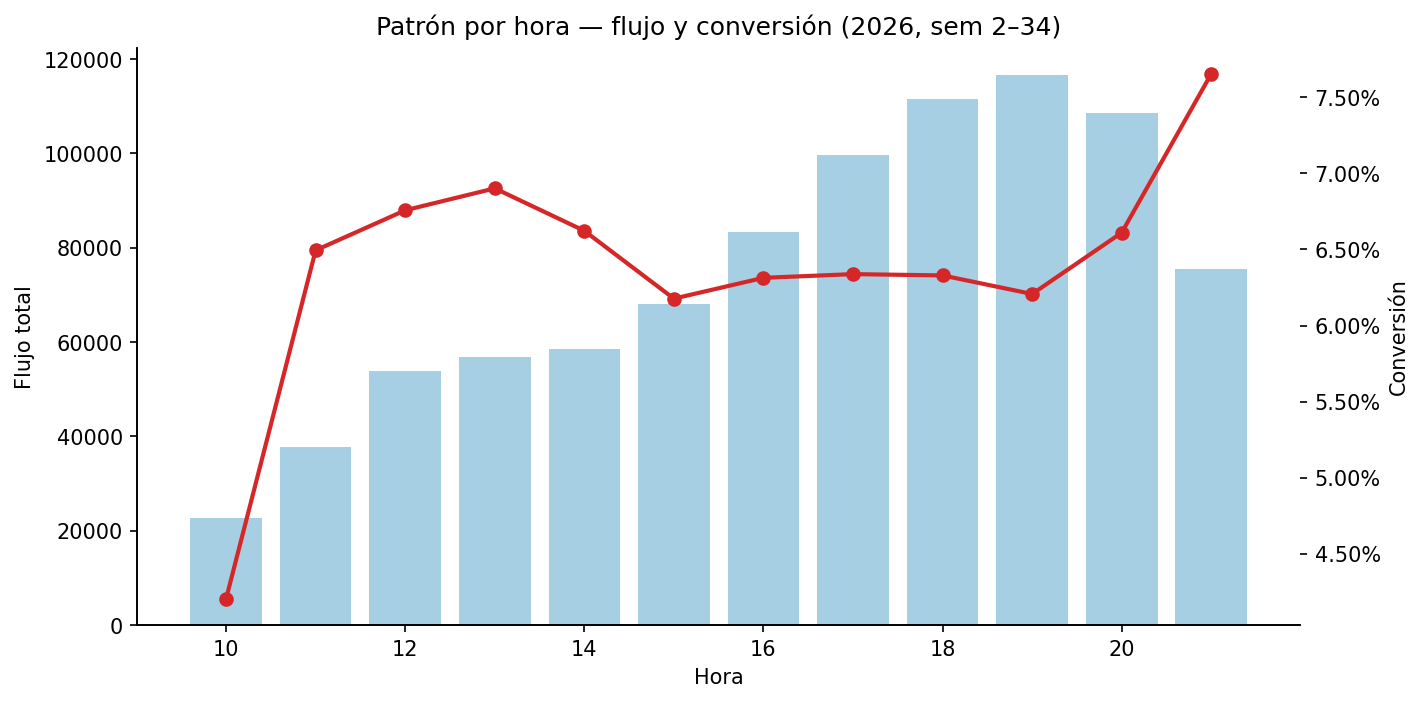

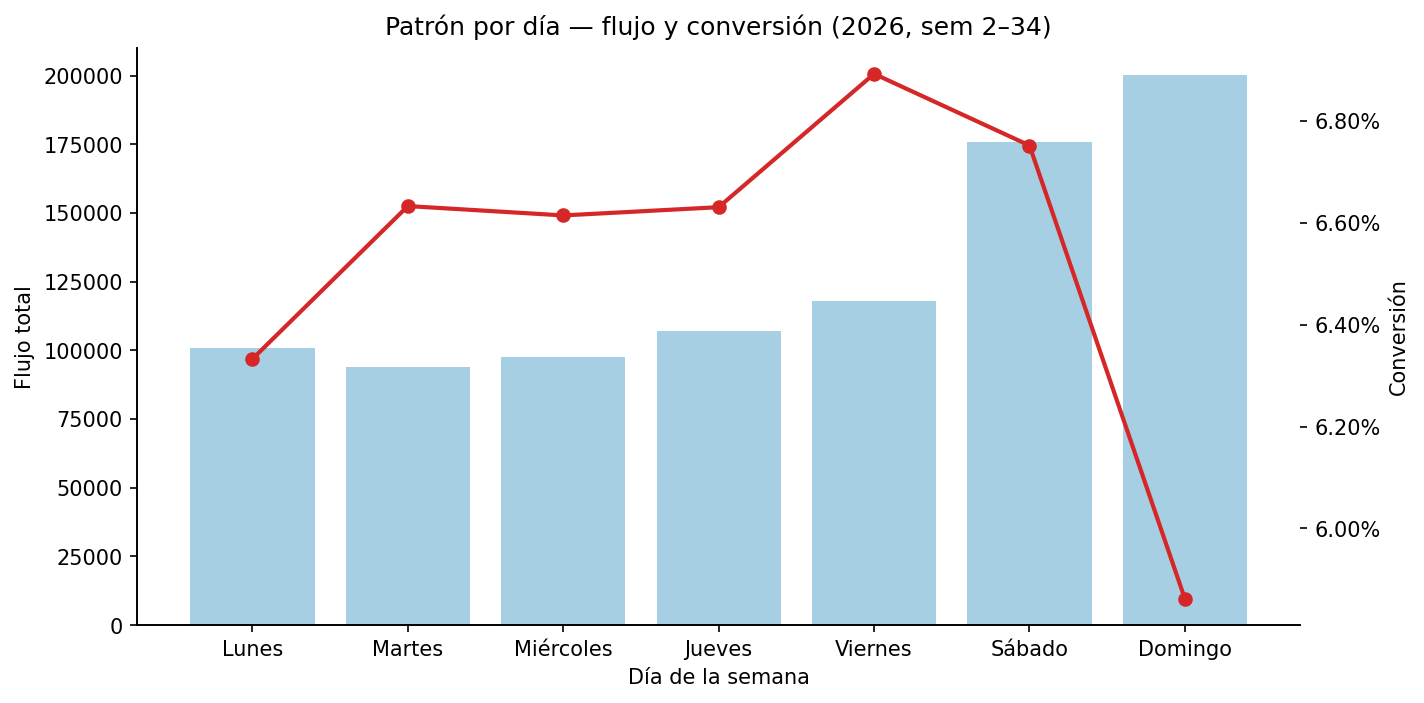

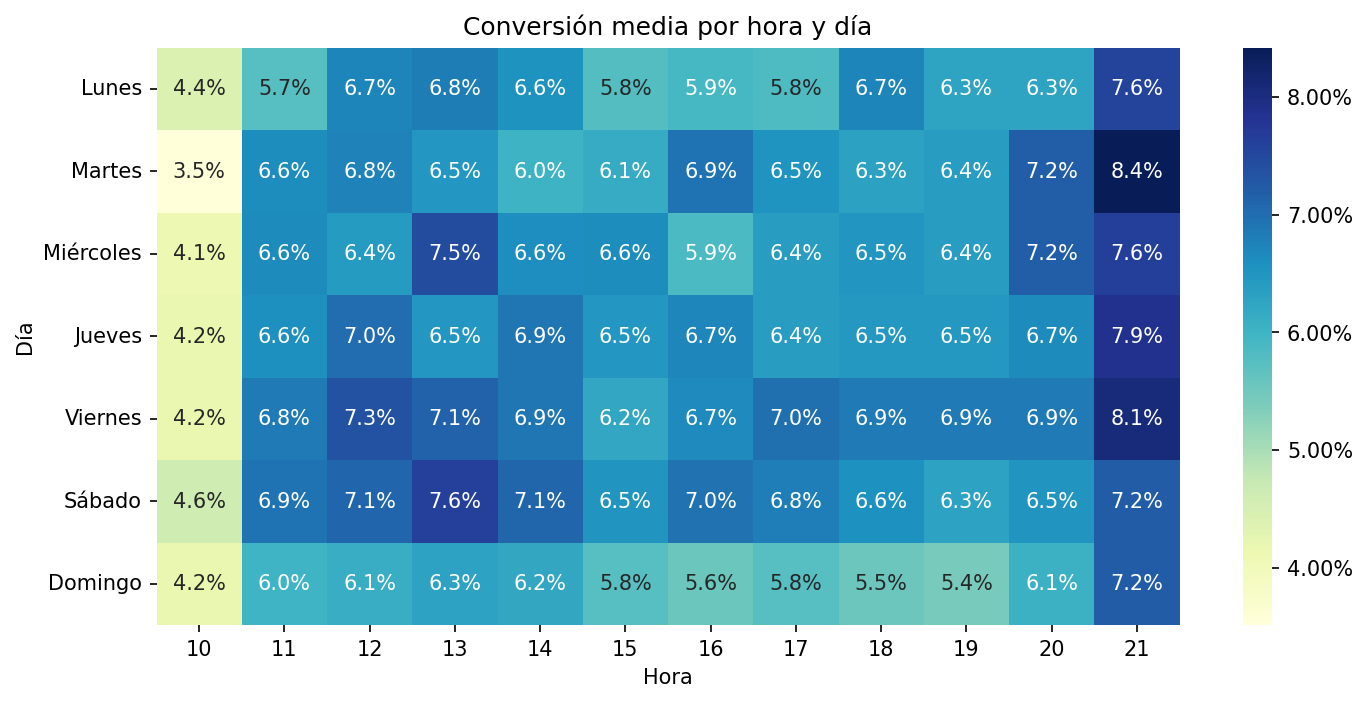

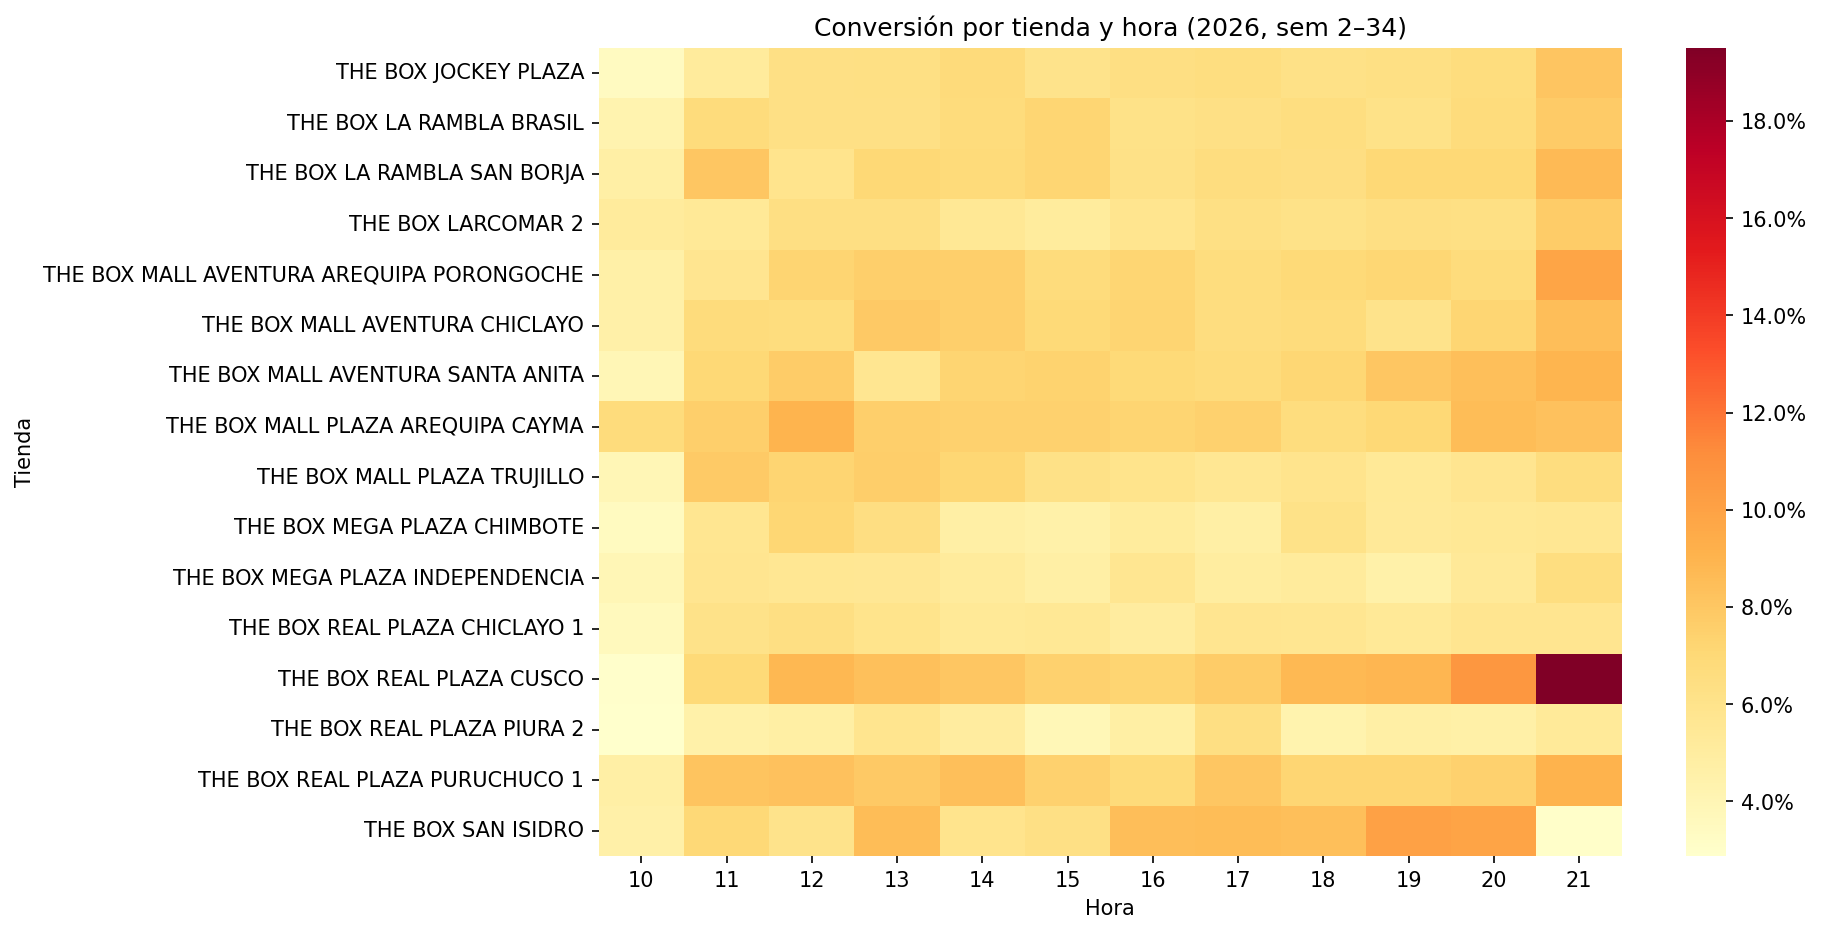

In [8]:
d26 = dep.loc[(dep['anio'] == 2026) & dep['semana'].between(2, 34)].copy()

por_hora = d26.groupby('hora').agg(flujo=('flujo', 'sum'), trx=('transacciones', 'sum'), venta=('venta', 'sum')).reset_index()
por_hora['share'] = por_hora['flujo'] / por_hora['flujo'].sum()
por_hora['conv'] = por_hora['trx'] / por_hora['flujo']
por_hora['ticket'] = por_hora['venta'] / por_hora['trx']

por_dia = (
    d26.assign(dow=d26['fecha'].dt.isocalendar().day.astype(int))
       .groupby('dow')
       .agg(flujo=('flujo', 'sum'),
            trx=('transacciones', 'sum'),
            venta=('venta', 'sum'),
            unid=('unidades', 'sum'))
       .reset_index()
)
por_dia['share'] = por_dia['flujo'] / por_dia['flujo'].sum()
por_dia['conv'] = por_dia['trx'] / por_dia['flujo']
por_dia['ticket'] = por_dia['venta'] / por_dia['trx']
por_dia['dia'] = por_dia['dow'].map(DAY_NAMES)

print(f"Conversión 10:00 = {por_hora.loc[por_hora['hora'] == 10, 'conv'].iat[0]*100:.2f}%")
print(f"Conversión resto del día = {por_hora.loc[por_hora['hora'] > 10, 'trx'].sum() / por_hora.loc[por_hora['hora'] > 10, 'flujo'].sum() * 100:.2f}%")
display(por_hora)
display(por_dia)

dual_axis_bar_line(por_hora, 'hora', 'flujo', 'conv',
                   'Patrón por hora — flujo y conversión (2026, sem 2–34)',
                   'Hora', 'Flujo total', 'Conversión', 'patron_hora.png')

dual_axis_bar_line(por_dia, 'dow', 'flujo', 'conv',
                   'Patrón por día — flujo y conversión (2026, sem 2–34)',
                   'Día de la semana', 'Flujo total', 'Conversión', 'patron_dia.png',
                   xlabels=por_dia['dia'])

heat_hd = (
    d26.assign(dow=d26['fecha'].dt.isocalendar().day.astype(int))
       .groupby(['dow', 'hora'])
       .agg(flujo=('flujo', 'sum'), trx=('transacciones', 'sum'))
       .reset_index()
)
heat_hd['conv'] = heat_hd['trx'] / heat_hd['flujo']
pivot_hd = heat_hd.pivot(index='dow', columns='hora', values='conv').reindex(sorted(DAY_NAMES))

plt.figure(figsize=(11, 5))
sns.heatmap(pivot_hd, cmap='YlGnBu', annot=True, fmt='.1%', cbar_kws={'format': mticker.PercentFormatter(1.0)})
plt.yticks(np.arange(len(pivot_hd.index)) + 0.5, [DAY_NAMES[i] for i in pivot_hd.index], rotation=0)
plt.title('Conversión media por hora y día')
plt.xlabel('Hora')
plt.ylabel('Día')
savefig('heatmap_hora_dia.png')

heat_th = d26.groupby(['nombre_tienda', 'hora']).agg(flujo=('flujo', 'sum'), trx=('transacciones', 'sum')).reset_index()
heat_th['conv'] = heat_th['trx'] / heat_th['flujo']
pivot_th = heat_th.pivot(index='nombre_tienda', columns='hora', values='conv')

plt.figure(figsize=(11, 7))
sns.heatmap(pivot_th, cmap='YlOrRd', annot=False, cbar_kws={'format': mticker.PercentFormatter(1.0)})
plt.title('Conversión por tienda y hora (2026, sem 2–34)')
plt.xlabel('Hora')
plt.ylabel('Tienda')
savefig('heatmap_tienda_hora.png')

analysis_summary['patrones'] = {
    'por_hora': por_hora.copy(),
    'por_dia': por_dia.copy()
}

# Bloque 8 — Posibles cambios de medición

**Pregunta.** ¿Existen tiendas con quiebres bruscos en flujo y conversión que sugieran cambios de medición del contador?

**Método.** Se inspeccionan las series semanales 2026 de San Isidro y Mega Plaza Chimbote en flujo, transacciones y conversión. Luego se compara la mejora de conversión 2025–2026 en tiendas comunes con y sin estas sedes.

> Un quiebre brusco es un **indicio** de cambio de medición, no una confirmación definitiva de falla del contador.

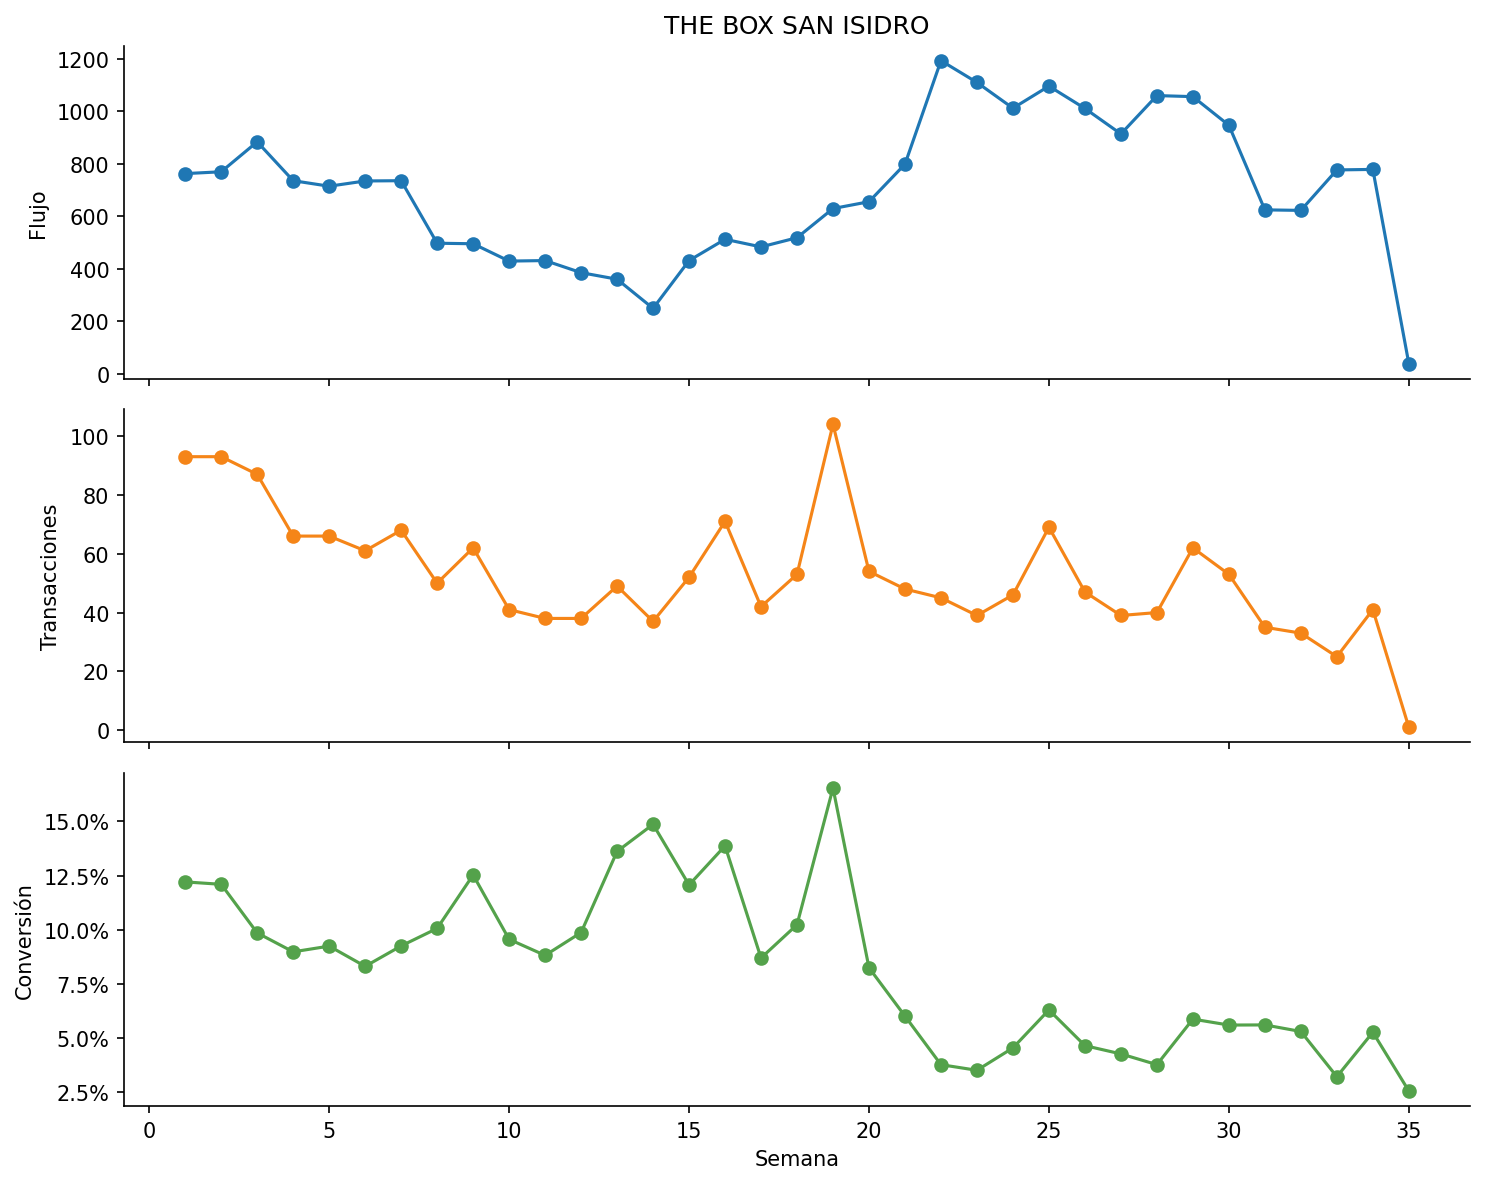

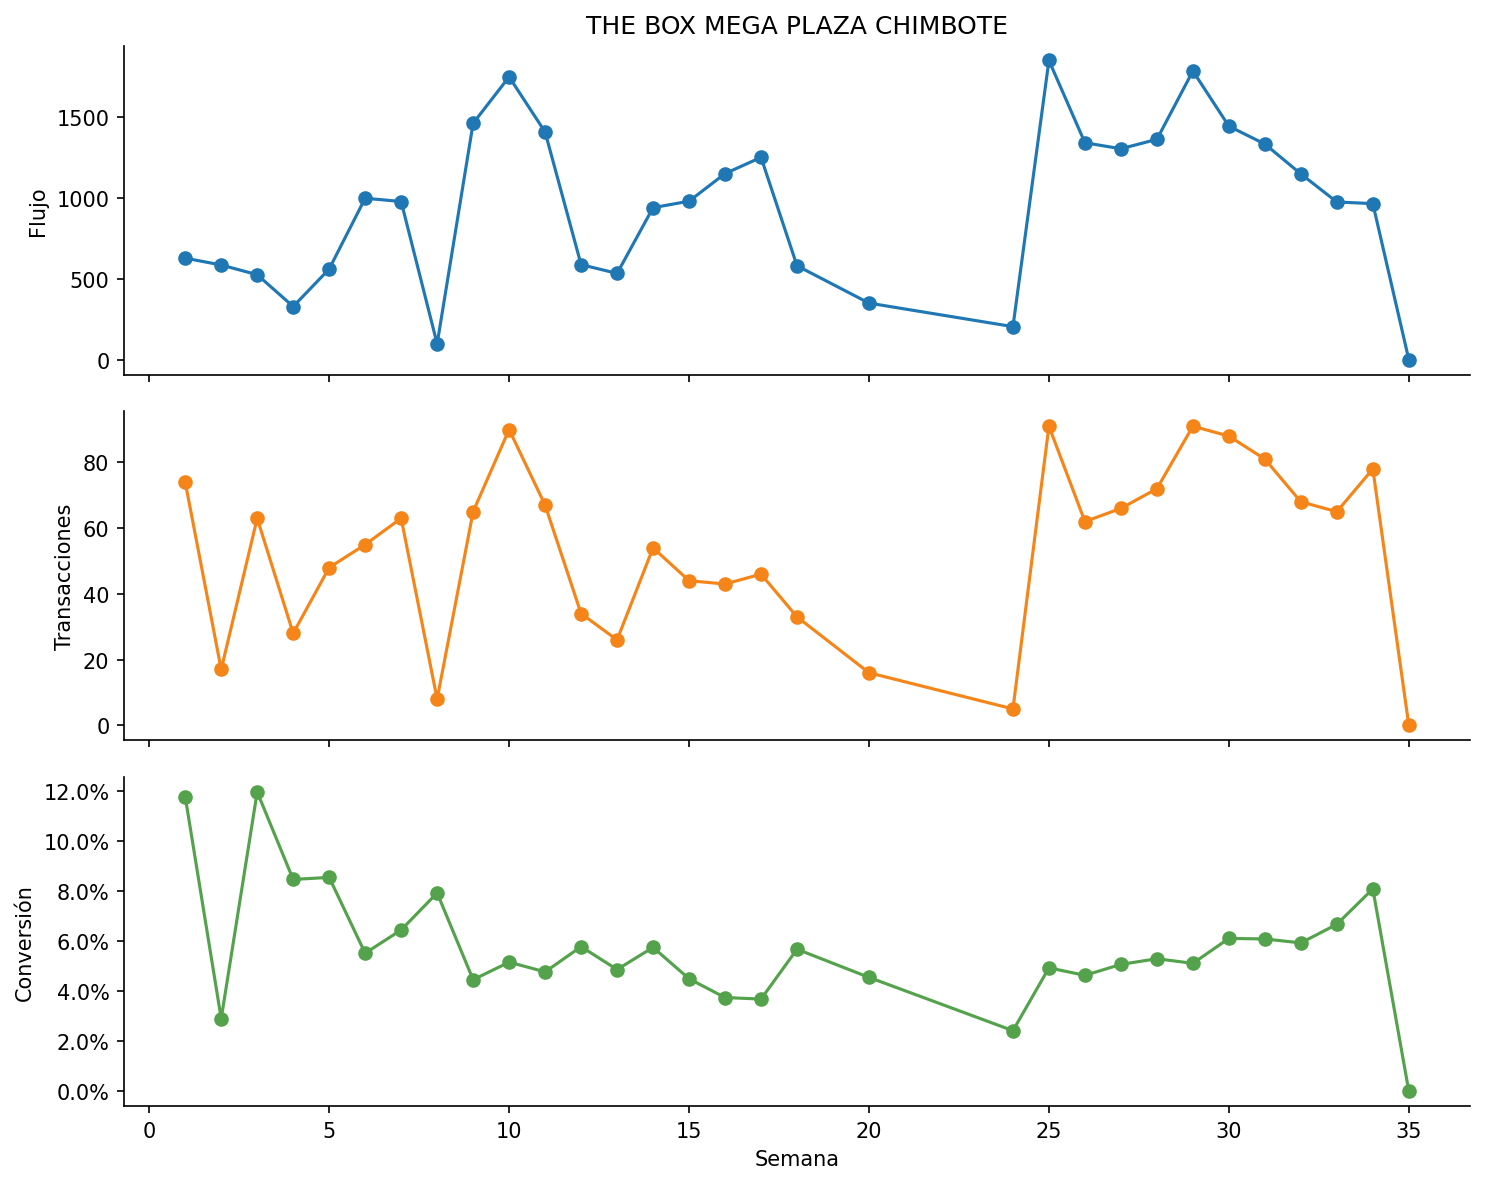

,flujo_sem,trx_sem,venta_sem,total_f,total_t,conv
tramo,,,,,,
sem 2-19,565.842105,61.631579,17860.163565,10751,1171,0.108920
sem 22-34,873.500000,41.071429,13883.563909,12229,575,0.047019


,escenario,conv_2025,conv_2026,mejora_pp
0,Todas,0.055610,0.065464,0.985398
1,Sin rupturas,0.054011,0.065608,1.159678


In [9]:
series_tiendas = {}
mapa_series = {
    'THE BOX SAN ISIDRO': 'serie_san_isidro.png',
    'THE BOX MEGA PLAZA CHIMBOTE': 'serie_chimbote.png'
}

for tienda, archivo in mapa_series.items():
    serie = (
        dep.loc[(dep['nombre_tienda'] == tienda) & (dep['anio'] == 2026)]
           .groupby('semana')
           .agg(f=('flujo', 'sum'), t=('transacciones', 'sum'), v=('venta', 'sum'))
           .reset_index()
    )
    serie['conv'] = serie['t'] / serie['f']
    series_tiendas[tienda] = serie

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(serie['semana'], serie['f'], marker='o')
    axes[0].set_ylabel('Flujo')
    axes[0].set_title(tienda)
    axes[1].plot(serie['semana'], serie['t'], marker='o', color='#F58518')
    axes[1].set_ylabel('Transacciones')
    axes[2].plot(serie['semana'], serie['conv'], marker='o', color='#54A24B')
    axes[2].set_ylabel('Conversión')
    axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].set_xlabel('Semana')
    plt.tight_layout()
    savefig(archivo)

san_isidro = series_tiendas['THE BOX SAN ISIDRO'].copy()
san_isidro_tramos = san_isidro.loc[(san_isidro['semana'] <= 19) | (san_isidro['semana'] >= 22)].copy()
san_isidro_tramos['tramo'] = np.where(san_isidro_tramos['semana'] <= 19, 'sem 2-19', 'sem 22-34')
resumen_si = (
    san_isidro_tramos.groupby('tramo')
                    .agg(flujo_sem=('f', 'mean'),
                         trx_sem=('t', 'mean'),
                         venta_sem=('v', 'mean'),
                         total_f=('f', 'sum'),
                         total_t=('t', 'sum'))
)
resumen_si['conv'] = resumen_si['total_t'] / resumen_si['total_f']
display(resumen_si)

comparacion_rupturas = []
for excl in [False, True]:
    d = dep.loc[dep['semana'].between(2, 34) & dep['nombre_tienda'].isin(comunes)].copy()
    if excl:
        d = d.loc[~d['nombre_tienda'].str.contains('SAN ISIDRO|CHIMBOTE', regex=True)].copy()
    r = d.groupby('anio').apply(lambda g: g['transacciones'].sum() / g['flujo'].sum())
    comparacion_rupturas.append({
        'escenario': 'Sin rupturas' if excl else 'Todas',
        'conv_2025': r.loc[2025],
        'conv_2026': r.loc[2026],
        'mejora_pp': 100 * (r.loc[2026] - r.loc[2025])
    })
comparacion_rupturas = pd.DataFrame(comparacion_rupturas)
display(comparacion_rupturas)

analysis_summary['medicion'] = {
    'san_isidro': san_isidro.copy(),
    'chimbote': series_tiendas['THE BOX MEGA PLAZA CHIMBOTE'].copy(),
    'resumen_si': resumen_si.reset_index().copy(),
    'comparacion_rupturas': comparacion_rupturas.copy()
}

# Bloque 9 — Metas comerciales

**Pregunta.** ¿Cómo se comporta el sistema de metas y qué relación descriptiva guarda con la conversión observada?

**Método.** Se usa la hoja `BD Cumplimiento de Meta de Vta`, ignorando columnas auxiliares `Unnamed:` y reteniendo las diez columnas útiles. Se resume el cumplimiento ponderado por año, la exigencia 2026 respecto a ventas 2025 y la correlación entre cumplimiento 2026 y conversión 2026.

> Una asociación entre conversión y cumplimiento comercial no prueba dirección causal: ambas pueden responder a mezcla de demanda, surtido, plaza o medición.

,anio,n,meta_total,venta_total,pct_sobre_80,pct_sobre_100,cumplimiento_ponderado
0,2025,736,3.611763e+07,2.447646e+07,0.255435,0.066576,0.677687
1,2026,523,2.973932e+07,2.187533e+07,0.353728,0.059273,0.735569


La meta 2026 exige +158.0% sobre la venta 2025.
Se logró +89.0%. Cumplimiento: 73.3%
Correlación cumplimiento 2026 vs conversión: r=-0.015, p=0.957


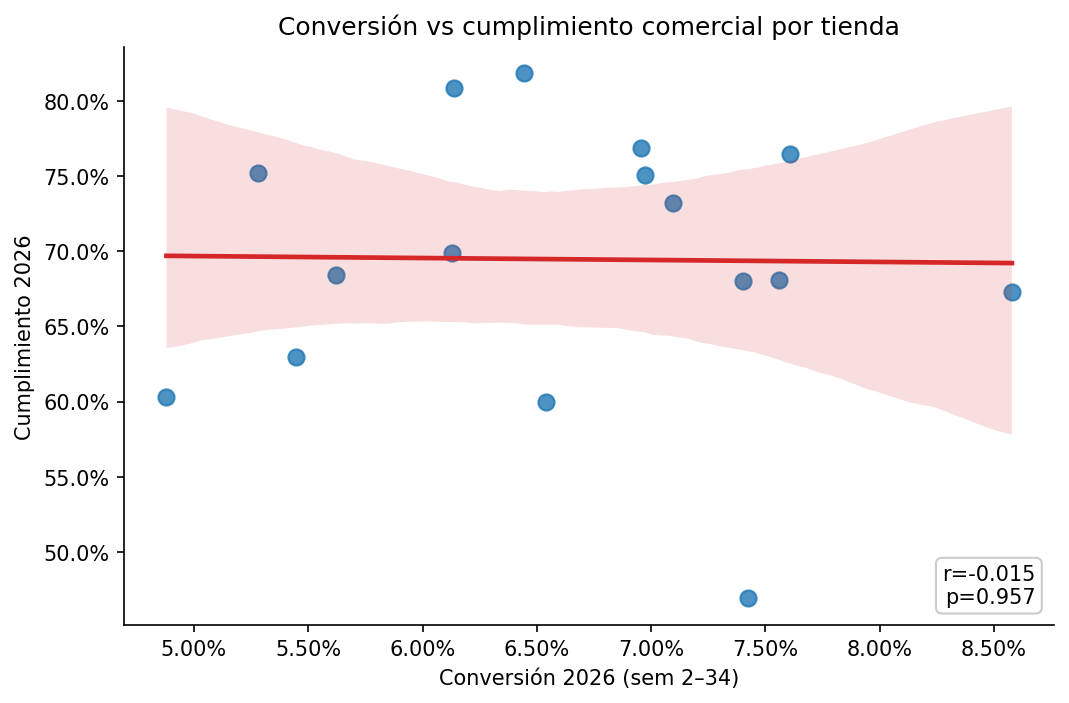

In [10]:
meta_raw = pd.read_excel(DATOS, sheet_name='BD Cumplimiento de Meta de Vta', usecols=list(range(1, 11)))
check_columns(meta_raw.columns.tolist(), EXPECTED_META, 'BD Cumplimiento de Meta de Vta')
meta_raw.columns = ['anio','mes','semana','categoria','nro_tienda','tienda',
                    'nombre_tienda','meta','venta_meta','cumplimiento']

meta = meta_raw.loc[(meta_raw['categoria'] == 'THE BOX') & meta_raw['meta'].notna() & (meta_raw['meta'] > 0)].copy()
meta[['anio','semana','meta','venta_meta']] = meta[['anio','semana','meta','venta_meta']].apply(pd.to_numeric, errors='coerce')
meta['cumpl'] = meta['venta_meta'] / meta['meta']

metas_resumen = meta.groupby('anio').agg(
    n=('anio', 'size'),
    meta_total=('meta', 'sum'),
    venta_total=('venta_meta', 'sum'),
    pct_sobre_80=('cumpl', lambda s: (s >= 0.80).mean()),
    pct_sobre_100=('cumpl', lambda s: (s >= 1.00).mean())
).reset_index()
metas_resumen['cumplimiento_ponderado'] = metas_resumen['venta_total'] / metas_resumen['meta_total']
display(metas_resumen)

v25 = meta.loc[(meta['anio'] == 2025) & meta['semana'].between(2, 34)].groupby('nombre_tienda').agg(v25=('venta_meta', 'sum')).reset_index()
v26 = meta.loc[(meta['anio'] == 2026) & meta['semana'].between(2, 34)].groupby('nombre_tienda').agg(meta26=('meta', 'sum'), v26=('venta_meta', 'sum')).reset_index()
exig = v25.merge(v26, on='nombre_tienda', how='inner')
exigencia_2026 = sum(exig['meta26']) / sum(exig['v25']) - 1
logro_2026 = sum(exig['v26']) / sum(exig['v25']) - 1
cumplimiento_global = sum(exig['v26']) / sum(exig['meta26'])
print(f'La meta 2026 exige {exigencia_2026*100:+.1f}% sobre la venta 2025.')
print(f'Se logró {logro_2026*100:+.1f}%. Cumplimiento: {cumplimiento_global*100:.1f}%')

cm = (meta.loc[(meta['anio'] == 2026) & meta['semana'].between(2, 34)]
        .groupby('nombre_tienda')
        .apply(lambda g: g['venta_meta'].sum() / g['meta'].sum())
        .reset_index(name='cumpl'))
jj = ct[['nombre_tienda', 'conv']].merge(cm, on='nombre_tienda', how='inner')
r_meta, p_meta = stats.pearsonr(jj['conv'], jj['cumpl'])
print(f'Correlación cumplimiento 2026 vs conversión: r={r_meta:.3f}, p={p_meta:.3f}')

plt.figure(figsize=(8, 5))
sns.regplot(data=jj, x='conv', y='cumpl', scatter_kws={'s': 60}, line_kws={'color': '#d62728'})
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xlabel('Conversión 2026 (sem 2–34)')
plt.ylabel('Cumplimiento 2026')
plt.title('Conversión vs cumplimiento comercial por tienda')
plt.annotate(f'r={r_meta:.3f}\np={p_meta:.3f}', xy=(0.98, 0.03), xycoords='axes fraction',
             ha='right', va='bottom', bbox=dict(boxstyle='round', fc='white', ec='0.8'))
savefig('metas_vs_conversion.png')

metas_resumen.to_csv(TAB / 'metas_resumen.csv', index=False)

analysis_summary['metas'] = {
    'metas_resumen': metas_resumen.copy(),
    'exigencia_2026': float(exigencia_2026),
    'logro_2026': float(logro_2026),
    'cumplimiento_global': float(cumplimiento_global),
    'corr': {'r': float(r_meta), 'p': float(p_meta)},
    'cruce': jj.copy()
}

# Bloque 10 — Impacto económico y sensibilidad

**Pregunta.** ¿Qué orden de magnitud económico tendría cerrar la brecha respecto a referencias internas observadas?

**Método.** Se usa el flujo 2026 depurado en semanas 2–34 y se anualiza con un factor estacional calculado con el flujo 2025 total sobre su tramo semanas 2–34. Luego se valora la brecha frente a p75, p90 y máximo usando el ticket promedio observado.

> La **venta potencial** es una referencia de orden de magnitud: **no es utilidad, ni impacto garantizado, ni evidencia causal**.

Factor estacional: 1.9009  — esperado: 1.9009
Flujo anual: 1,697,953  — esperado: 1,697,953
Ticket: S/354.90  — esperado: S/354.90
Brecha p90: 1.3025 pp  — esperado: 1.3025 pp
Trx extra: 22,116  — esperado: 22,116
Venta extra: S/7.85M  — esperado: S/7.85M


,escenario,frontera,brecha_pp,flujo_anual,trx_extra,venta_extra_MM
0,p75,0.071980,0.715716,1.697953e+06,12152.526863,4.312982
1,p90,0.077848,1.302507,1.697953e+06,22115.966524,7.849048
2,max,0.085843,2.102034,1.697953e+06,35691.564464,12.667084


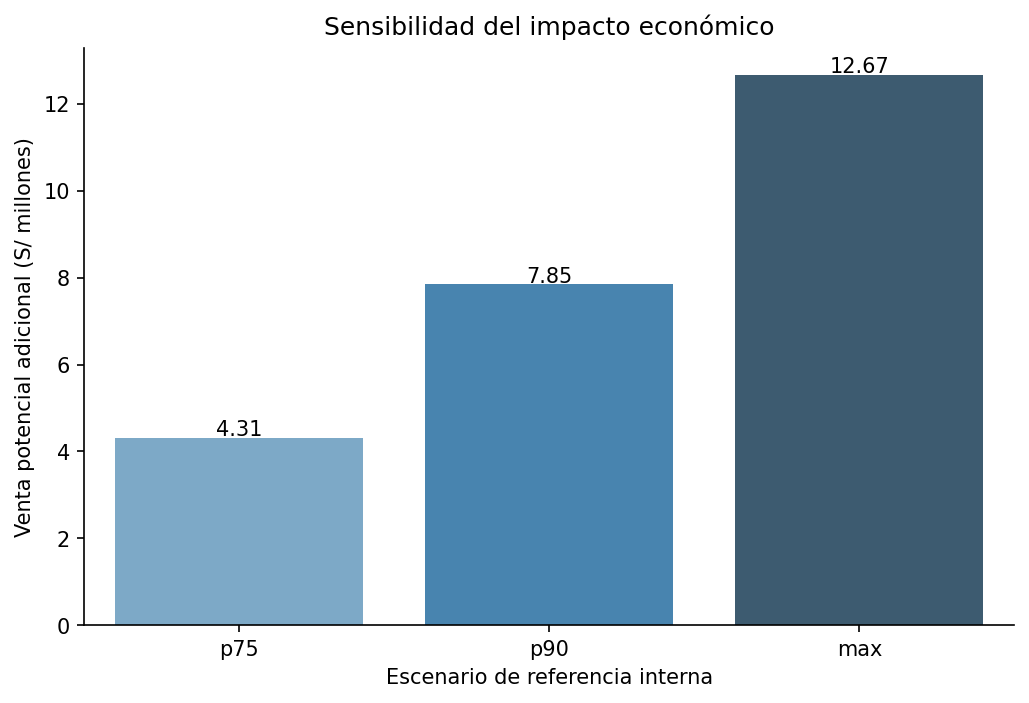

In [11]:
w25 = tb.loc[tb['anio'] == 2025].groupby('semana')['flujo'].sum().reset_index(name='f')
factor_est = w25['f'].sum() / w25.loc[w25['semana'].between(2, 34), 'f'].sum()
flujo_26 = dep.loc[(dep['anio'] == 2026) & dep['semana'].between(2, 34), 'flujo'].sum()
flujo_anual = flujo_26 * factor_est
ticket = sw26['v'].sum() / sw26['t'].sum()

escenarios = []
for etiqueta, p in [('p75', 0.75), ('p90', 0.90), ('max', 1.00)]:
    frontera_val = weighted_frontier(sw26, p)
    brecha = frontera_val - conv_real
    trx_extra = flujo_anual * brecha
    venta_extra = trx_extra * ticket
    escenarios.append({
        'escenario': etiqueta,
        'frontera': frontera_val,
        'brecha_pp': 100 * brecha,
        'flujo_anual': flujo_anual,
        'trx_extra': trx_extra,
        'venta_extra_MM': venta_extra / 1e6
    })
escenarios = pd.DataFrame(escenarios)
escenarios.to_csv(TAB / 'impacto_economico_escenarios.csv', index=False)

brecha_p90 = escenarios.loc[escenarios['escenario'] == 'p90', 'brecha_pp'].iat[0] / 100
trx_extra_p90 = flujo_anual * brecha_p90
venta_extra_p90 = trx_extra_p90 * ticket

print(f"Factor estacional: {factor_est:.4f}  — esperado: 1.9009")
print(f"Flujo anual: {flujo_anual:,.0f}  — esperado: 1,697,953")
print(f"Ticket: S/{ticket:.2f}  — esperado: S/354.90")
print(f"Brecha p90: {brecha_p90*100:.4f} pp  — esperado: 1.3025 pp")
print(f"Trx extra: {trx_extra_p90:,.0f}  — esperado: 22,116")
print(f"Venta extra: S/{venta_extra_p90/1e6:.2f}M  — esperado: S/7.85M")
display(escenarios)

plt.figure(figsize=(8, 5))
sns.barplot(data=escenarios, x='escenario', y='venta_extra_MM', palette='Blues_d')
plt.ylabel('Venta potencial adicional (S/ millones)')
plt.xlabel('Escenario de referencia interna')
plt.title('Sensibilidad del impacto económico')
for i, row in escenarios.reset_index().iterrows():
    plt.text(i, row['venta_extra_MM'] + 0.05, f"{row['venta_extra_MM']:.2f}", ha='center')
savefig('impacto_escenarios.png')

analysis_summary['impacto'] = {
    'factor_est': float(factor_est),
    'flujo_anual': float(flujo_anual),
    'ticket': float(ticket),
    'escenarios': escenarios.copy()
}

# Bloque 11 — Síntesis del diagnóstico y próximos pasos

## Resumen interpretativo

- **Hallazgos verificados:** la depuración reduce sesgos mecánicos de conversión; la mejora 2026 vs 2025 existe, pero no se explica solo por mayor tráfico; la variación dentro de tienda supera a la dispersión entre tiendas; y hay quiebres fuertes en ciertas sedes consistentes con problemas de medición.
- **Asociaciones estadísticas:** tráfico y conversión se relacionan negativamente en varias especificaciones; conversión y cumplimiento comercial pueden moverse juntas; las primeras horas y algunos días concentran peores tasas.
- **Hipótesis de trabajo:** congestión, mezcla distinta de visitantes, operación por franja y calidad del conteo pueden explicar parte de la brecha. Ninguna queda confirmada solo con estas correlaciones.

## Matriz de hallazgos

| Hallazgo | Evidencia | Implicación TFIE | Validación pendiente |
|---|---|---|---|
| Registros incompatibles sesgan la conversión | Flujo cero, hora 22 y casos con flujo<trx | Depurar es requisito para diagnosticar | Revisar reglas del contador y cierres |
| La mejora interanual es real pero heterogénea | Venta y conversión suben en semanas comparables | No basta una lectura agregada | Separar efecto de aperturas y mix |
| El benchmark útil es interno | p75/p90 salen del propio historial de tiendas | Sirve para priorizar brechas | Ver sostenibilidad operativa del p90 |
| Más tráfico se asocia con menor conversión | Paneles y Spearman negativos | Riesgo de congestión o mezcla adversa | Medir aforo, colas y staffing por hora |
| La relación no es causal | FE no eliminan todos los confusores | Evita concluir “falta personal” solo con regresiones | Diseños cuasi-experimentales u operativos |
| La oportunidad está dentro de tienda | SD dentro > SD entre; R² parcial de semana | La mejora depende de gestión fina | Auditar microprocesos y turnos |
| Existen franjas débiles | Conversión más baja a primera hora y en domingo | Priorizar acciones por franja | Revisar apertura, visual y propuesta |
| San Isidro y Chimbote presentan quiebres | Saltos bruscos de flujo con caída de conversión | Posible problema de medición | Contrastar con logs del contador |
| Metas y conversión pueden estar vinculadas | Correlación positiva/negativa según estimación | El sistema comercial puede amplificar brechas | Integrar metas con capacidad operativa |
| El impacto económico es referencial | Escenarios p75/p90/max dependen de supuestos | Útil para priorizar, no para prometer utilidades | Validar con pilotos y seguimiento |

## Próximos pasos de validación

1. Auditar el sistema de conteo en tiendas con quiebres y documentar cualquier recalibración.
2. Levantar aforo, colas, cobertura de personal y tiempos de atención por franja.
3. Separar tráfico “frío” vs “caliente” si existe información de campañas o plaza.
4. Probar pilotos focalizados por hora/tienda y medir impacto con diseños antes-después bien controlados.
5. Revisar si las metas comerciales consideran capacidad operativa y calidad de medición.

In [12]:
verificacion_vs_r = pd.DataFrame([
    {'metrica': 'conv_reportada_2025', 'actual': calidad_comp.loc[calidad_comp['anio'] == 2025, 'conv_reportada'].iat[0], 'esperado': 0.06468},
    {'metrica': 'conv_reportada_2026', 'actual': calidad_comp.loc[calidad_comp['anio'] == 2026, 'conv_reportada'].iat[0], 'esperado': 0.06815},
    {'metrica': 'conv_dep_2025', 'actual': conv_dep.loc[conv_dep['anio'] == 2025, 'conv_depurada'].iat[0], 'esperado': 0.05973},
    {'metrica': 'conv_dep_2026', 'actual': conv_dep.loc[conv_dep['anio'] == 2026, 'conv_depurada'].iat[0], 'esperado': 0.06467},
    {'metrica': 'crecimiento_venta', 'actual': analysis_summary['evolucion']['crecimiento_total'], 'esperado': 0.941},
    {'metrica': 'aporte_flujo', 'actual': decomp.loc[0, 'aporte_pct'] / 100, 'esperado': 0.359},
    {'metrica': 'aporte_conversion', 'actual': decomp.loc[1, 'aporte_pct'] / 100, 'esperado': 0.165},
    {'metrica': 'aporte_ticket', 'actual': decomp.loc[2, 'aporte_pct'] / 100, 'esperado': 0.475},
    {'metrica': 'crecimiento_tiendas_comunes', 'actual': analysis_summary['evolucion']['crecimiento_comunes'], 'esperado': 0.759},
    {'metrica': 'frontier_p75', 'actual': analysis_summary['frontera']['frontiers'].loc[analysis_summary['frontera']['frontiers']['percentil'] == 0.75, 'frontera'].iat[0], 'esperado': 0.071980},
    {'metrica': 'frontier_p90', 'actual': analysis_summary['frontera']['frontiers'].loc[analysis_summary['frontera']['frontiers']['percentil'] == 0.90, 'frontera'].iat[0], 'esperado': 0.077848},
    {'metrica': 'frontier_max', 'actual': analysis_summary['frontera']['frontiers'].loc[analysis_summary['frontera']['frontiers']['percentil'] == 1.00, 'frontera'].iat[0], 'esperado': 0.085843},
    {'metrica': 'm1_beta', 'actual': analysis_summary['trafico_conversion']['m1']['beta'], 'esperado': -0.01583},
    {'metrica': 'm2_beta', 'actual': analysis_summary['trafico_conversion']['m2']['beta'], 'esperado': -0.04897},
    {'metrica': 'pearson', 'actual': analysis_summary['trafico_conversion']['ct']['pearson_r'], 'esperado': -0.378},
    {'metrica': 'spearman', 'actual': analysis_summary['trafico_conversion']['ct']['spearman_r'], 'esperado': -0.615},
    {'metrica': 'r2_tienda', 'actual': analysis_summary['varianza']['r2_tienda'], 'esperado': 0.332},
    {'metrica': 'r2_semana', 'actual': analysis_summary['varianza']['r2_semana'], 'esperado': 0.080},
    {'metrica': 'r2_ambos', 'actual': analysis_summary['varianza']['r2_ambos'], 'esperado': 0.420},
    {'metrica': 'sd_entre', 'actual': analysis_summary['varianza']['sd_entre'], 'esperado': 0.00999},
    {'metrica': 'sd_dentro', 'actual': analysis_summary['varianza']['sd_dentro'], 'esperado': 0.01200},
    {'metrica': 'factor_est', 'actual': analysis_summary['impacto']['factor_est'], 'esperado': 1.9009},
    {'metrica': 'ticket', 'actual': analysis_summary['impacto']['ticket'], 'esperado': 354.90}
])
verificacion_vs_r['dif'] = verificacion_vs_r['actual'] - verificacion_vs_r['esperado']
verificacion_vs_r.to_csv(TAB / 'verificacion_vs_r.csv', index=False)

escenarios = analysis_summary['impacto']['escenarios'].copy()
metas_resumen = analysis_summary['metas']['metas_resumen'].copy()
comparacion_rupturas = analysis_summary['medicion']['comparacion_rupturas'].copy()
resumen_si = analysis_summary['medicion']['resumen_si'].copy()

frontiers = analysis_summary['frontera']['frontiers'].set_index('percentil')
calidad_res = analysis_summary['calidad']['calidad'].set_index('anio')
conv_dep_res = analysis_summary['calidad']['conv_dep'].set_index('anio')
comp_res = analysis_summary['evolucion']['comp'].set_index('anio')
comunes_res = analysis_summary['evolucion']['comp_comunes'].set_index('anio')
modelos = analysis_summary['trafico_conversion']['modelos'].copy()

resumen_ejecutivo = (
    f"Entre 2025 y 2026, The Box mejora su desempeño en semanas comparables: la venta crece {analysis_summary['evolucion']['crecimiento_total']*100:.1f}% "
    f"y la conversión depurada sube de {conv_dep_res.loc[2025, 'conv_depurada']*100:.2f}% a {conv_dep_res.loc[2026, 'conv_depurada']*100:.2f}%. "
    f"La descomposición logarítmica sugiere que el crecimiento se reparte entre mayor flujo ({decomp.loc[0, 'aporte_pct']:.1f}% del crecimiento), mejor conversión ({decomp.loc[1, 'aporte_pct']:.1f}%) "
    f"y mayor ticket ({decomp.loc[2, 'aporte_pct']:.1f}%). En 2026, la conversión real de semanas 2–34 es {conv_real*100:.2f}% y la frontera interna p90 llega a "
    f"{frontiers.loc[0.90, 'frontera']*100:.2f}%, lo que deja una brecha referencial de {frontiers.loc[0.90, 'brecha_pp']:.2f} pp. "
    f"Las regresiones y correlaciones muestran una asociación negativa entre tráfico y conversión, pero no permiten atribuir causalidad. "
    f"Además, San Isidro y Mega Plaza Chimbote muestran quiebres consistentes con posibles cambios de medición. "
    f"Si la organización cerrara de forma sostenible la brecha frente a p90 bajo los supuestos usados aquí, la venta potencial referencial sería de S/{escenarios.loc[escenarios['escenario']=='p90', 'venta_extra_MM'].iat[0]:.2f} millones anuales."
)

hallazgos_md = pd.DataFrame([
    ['Depuración necesaria', 'Flujo cero, hora 22 y casos flujo<trx', 'Evita sobreestimar o subestimar conversión', 'Auditar contador y cierres'],
    ['Mejora interanual real', 'Venta y conversión depurada suben', 'Hay progreso, pero no uniforme', 'Separar mix y aperturas'],
    ['Benchmark interno útil', 'p75/p90 salen del propio historial', 'Sirve para priorizar brechas', 'Probar sostenibilidad operativa'],
    ['Relación tráfico-conversión negativa', 'Paneles y Spearman negativos', 'Sugiere congestión o mix adverso', 'Medir aforo, colas y staffing'],
    ['No causalidad', 'Efectos fijos no bastan', 'Evita sobrerreaccionar con una sola palanca', 'Diseños cuasi-experimentales'],
    ['Oportunidad dentro de tienda', 'SD dentro > SD entre', 'Gestionar ejecución fina por semana/hora', 'Monitoreo operacional detallado'],
    ['Posibles quiebres de medición', 'San Isidro y Chimbote saltan en flujo', 'Prioridad de control tecnológico', 'Revisar logs/calibraciones'],
    ['Impacto económico referencial', 'Escenarios p75/p90/max', 'Útil para priorización, no promesa', 'Validar con pilotos']
], columns=['Hallazgo', 'Evidencia', 'Implicación TFIE', 'Validación pendiente'])

md = f"""# Conclusiones — The Box

## Resumen ejecutivo

{resumen_ejecutivo}

## Metodología y definición de muestras

- **Fuente:** `BD The Box Presentacion 30.08.xlsx`
- **raw:** todos los registros `THE BOX`.
- **dep:** registros con `hora` entre 10 y 21, `flujo > 0` y `flujo >= transacciones`.
- **comp/sw26:** semanas 2–34 del año correspondiente.
- **tiendas comunes:** tiendas presentes en 2025 y 2026 dentro de `dep`, semanas 2–34.
- **Conversión:** `transacciones / flujo`.

## Resultados por bloque

### 1. Estructura y cobertura
- Filas totales de la hoja operativa: {analysis_summary['raw']['raw_rows']:,}
- Filas THE BOX: {analysis_summary['raw']['tb_rows']:,}
- Tiendas únicas THE BOX: {analysis_summary['raw']['unique_stores']}

### 2. Calidad de datos y depuración
- Conversión reportada 2025: {calidad_res.loc[2025, 'conv_reportada']*100:.3f}%
- Conversión reportada 2026: {calidad_res.loc[2026, 'conv_reportada']*100:.3f}%
- Conversión depurada 2025: {conv_dep_res.loc[2025, 'conv_depurada']*100:.3f}%
- Conversión depurada 2026: {conv_dep_res.loc[2026, 'conv_depurada']*100:.3f}%
- Tabla: `outputs/tablas/calidad_datos.csv`

### 3. Evolución 2025–2026
- Crecimiento de venta: {analysis_summary['evolucion']['crecimiento_total']*100:+.1f}%
- Aporte flujo: {decomp.loc[0, 'aporte_pct']:.1f}%
- Aporte conversión: {decomp.loc[1, 'aporte_pct']:.1f}%
- Aporte ticket: {decomp.loc[2, 'aporte_pct']:.1f}%
- Crecimiento en tiendas comunes: {analysis_summary['evolucion']['crecimiento_comunes']*100:+.1f}%
- Gráficos: `outputs/figuras/evolucion_descomposicion.png`, `outputs/figuras/evolucion_conversion_semanal.png`

### 4. Conversión real y referencia interna
- Conversión real 2026 (sem 2–34): {conv_real*100:.4f}%
- Frontera p75: {frontiers.loc[0.75, 'frontera']*100:.4f}%
- Frontera p90: {frontiers.loc[0.90, 'frontera']*100:.4f}%
- Frontera máximo: {frontiers.loc[1.00, 'frontera']*100:.4f}%
- Tabla: `outputs/tablas/frontera_por_tienda.csv`
- Gráfico: `outputs/figuras/frontera_conversion.png`

### 5. Relación tráfico–conversión
- Panel hora: beta={analysis_summary['trafico_conversion']['m1']['beta']:.5f}, p={analysis_summary['trafico_conversion']['m1']['pvalue']:.4f}
- Efecto de +10% flujo horario: {analysis_summary['trafico_conversion']['m1']['effect_10pct_pp']:.4f} pp
- Panel semana: beta={analysis_summary['trafico_conversion']['m2']['beta']:.5f}, p={analysis_summary['trafico_conversion']['m2']['pvalue']:.4f}
- Pearson: r={analysis_summary['trafico_conversion']['ct']['pearson_r']:.3f}, p={analysis_summary['trafico_conversion']['ct']['pearson_p']:.3f}
- Spearman: r={analysis_summary['trafico_conversion']['ct']['spearman_r']:.3f}, p={analysis_summary['trafico_conversion']['ct']['spearman_p']:.3f}
- Tabla: `outputs/tablas/modelos_trafico_conversion.csv`
- Gráfico: `outputs/figuras/scatter_flujo_conversion.png`

### 6. Varianza dentro y entre tiendas
- R² tienda: {analysis_summary['varianza']['r2_tienda']:.3f}
- R² semana: {analysis_summary['varianza']['r2_semana']:.3f}
- R² ambos: {analysis_summary['varianza']['r2_ambos']:.3f}
- SD entre tiendas: {analysis_summary['varianza']['sd_entre']:.5f}
- SD dentro de tienda (promedio): {analysis_summary['varianza']['sd_dentro']:.5f}
- Gráfico: `outputs/figuras/varianza_conversion_tienda.png`

### 7. Patrones por hora y día
- Conversión a las 10:00: {analysis_summary['patrones']['por_hora'].loc[analysis_summary['patrones']['por_hora']['hora']==10, 'conv'].iat[0]*100:.2f}%
- Conversión resto del día: {analysis_summary['patrones']['por_hora'].loc[analysis_summary['patrones']['por_hora']['hora']>10, 'trx'].sum() / analysis_summary['patrones']['por_hora'].loc[analysis_summary['patrones']['por_hora']['hora']>10, 'flujo'].sum() * 100:.2f}%
- Gráficos: `outputs/figuras/patron_hora.png`, `outputs/figuras/patron_dia.png`, `outputs/figuras/heatmap_hora_dia.png`, `outputs/figuras/heatmap_tienda_hora.png`

### 8. Posibles cambios de medición
- San Isidro antes/después: flujo {resumen_si.loc[resumen_si['tramo']=='sem 2-19', 'flujo_sem'].iat[0]:.0f} → {resumen_si.loc[resumen_si['tramo']=='sem 22-34', 'flujo_sem'].iat[0]:.0f}; conversión {resumen_si.loc[resumen_si['tramo']=='sem 2-19', 'conv'].iat[0]*100:.2f}% → {resumen_si.loc[resumen_si['tramo']=='sem 22-34', 'conv'].iat[0]*100:.2f}%
- Mejora con todas las tiendas: {comparacion_rupturas.loc[comparacion_rupturas['escenario']=='Todas', 'mejora_pp'].iat[0]:.2f} pp
- Mejora sin rupturas: {comparacion_rupturas.loc[comparacion_rupturas['escenario']=='Sin rupturas', 'mejora_pp'].iat[0]:.2f} pp
- Gráficos: `outputs/figuras/serie_san_isidro.png`, `outputs/figuras/serie_chimbote.png`

### 9. Metas comerciales
- Cumplimiento ponderado 2025: {metas_resumen.loc[metas_resumen['anio']==2025, 'cumplimiento_ponderado'].iat[0]*100:.2f}%
- Cumplimiento ponderado 2026: {metas_resumen.loc[metas_resumen['anio']==2026, 'cumplimiento_ponderado'].iat[0]*100:.2f}%
- Exigencia meta 2026 vs venta 2025: {analysis_summary['metas']['exigencia_2026']*100:+.1f}%
- Logro real 2026 vs venta 2025: {analysis_summary['metas']['logro_2026']*100:+.1f}%
- Correlación conversión-cumplimiento: r={analysis_summary['metas']['corr']['r']:.3f}, p={analysis_summary['metas']['corr']['p']:.3f}
- Gráfico: `outputs/figuras/metas_vs_conversion.png`

### 10. Impacto económico y sensibilidad
- Factor estacional: {analysis_summary['impacto']['factor_est']:.4f}
- Flujo anual equivalente: {analysis_summary['impacto']['flujo_anual']:,.0f}
- Ticket promedio: S/{analysis_summary['impacto']['ticket']:.2f}
- Escenario p90: {escenarios.loc[escenarios['escenario']=='p90', 'brecha_pp'].iat[0]:.4f} pp, {escenarios.loc[escenarios['escenario']=='p90', 'trx_extra'].iat[0]:,.0f} transacciones y S/{escenarios.loc[escenarios['escenario']=='p90', 'venta_extra_MM'].iat[0]:.2f} MM
- Tabla: `outputs/tablas/impacto_economico_escenarios.csv`
- Gráfico: `outputs/figuras/impacto_escenarios.png`

## Supuestos del impacto económico

- El flujo 2026 de semanas 2–34 representa el patrón operativo base.
- La anualización usa el factor estacional observado en 2025.
- El ticket promedio permanece constante al cerrar la brecha de conversión.
- El benchmark p75/p90/max proviene del propio historial semanal de las tiendas.
- La venta potencial es una referencia bruta, no utilidad ni impacto garantizado.

## Limitaciones

- Correlación no implica causalidad.
- Los efectos fijos no eliminan todos los confusores.
- El p90 es referencia interna, no meta sostenible demostrada.
- Los cambios bruscos de flujo son indicios de medición, no confirmación de falla.
- El impacto económico depende de supuestos de estacionalidad, ticket y sostenibilidad.

## Próximos pasos

1. Auditar contadores de tráfico en San Isidro y Mega Plaza Chimbote.
2. Medir aforo, colas, staffing y tiempos de atención por franja.
3. Diseñar pilotos operativos con evaluación antes-después y controles.
4. Revisar la alineación entre metas comerciales y capacidad operativa.
5. Integrar monitoreo de calidad de dato en la rutina comercial.

## Matriz final de hallazgos

{hallazgos_md.to_markdown(index=False)}

## Verificación contra valores esperados del script R

Tabla: `outputs/tablas/verificacion_vs_r.csv`
"""

(REPO / 'conclusiones_the_box.md').write_text(md, encoding='utf-8')
print('Archivo generado:', REPO / 'conclusiones_the_box.md')
display(verificacion_vs_r)

Archivo generado: C:\Users\ADMIN\Desktop\UP\TRABAJO FINAL INGENIERÍA EMPRESARIAL\TFIE_26_2\conclusiones_the_box.md


,metrica,actual,esperado,dif
0,conv_reportada_2025,0.064680,0.064680,4.881710e-07
1,conv_reportada_2026,0.068147,0.068150,-3.143213e-06
2,conv_dep_2025,0.059662,0.059730,-6.794471e-05
3,conv_dep_2026,0.064744,0.064670,7.384068e-05
4,crecimiento_venta,1.026187,0.941000,8.518742e-02
5,aporte_flujo,0.337705,0.359000,-2.129475e-02
6,aporte_conversion,0.216914,0.165000,5.191399e-02
7,aporte_ticket,0.445381,0.475000,-2.961924e-02
8,crecimiento_tiendas_comunes,0.852020,0.759000,9.301994e-02
9,frontier_p75,0.071980,0.071980,-2.824291e-08
